### *Python programming for Google Earth Engine*
# **Week 2-2. Time Series of MODIS temperature for Heat Island**

# **Install necessary library**

In [ ]:
# Install geemap library
# !pip install geemap

# **Import necessary libraries**

In [290]:
# Import geemap library
import geemap
import ee
import os

In [ ]:
ee.Authenticate()

To authorize access needed by Earth Engine, open the following URL in a web browser and follow the instructions. If the web browser does not start automatically, please manually browse the URL below.

    https://code.earthengine.google.com/client-auth?scopes=https%3A//www.googleapis.com/auth/earthengine%20https%3A//www.googleapis.com/auth/devstorage.full_control&request_id=9MjHlhKJOSZWvUNK2WWYs-uwuQWKSQrGxxgn85V7yfY&tc=2ijrfQt08Ks-hyij3U6zsC1HDOcLjAA7KTmVI1tL9xM&cc=_GWFWrt8oZkv979GIBZLHQsFyPkbvy1OBTT-fGYnOY4

The authorization workflow will generate a code, which you should paste in the box below.
Enter verification code: 4/1ARtbsJr7ykjz25J3fVv_uDOkWqjHN7xLa1gUa4wSn02KvkTfUxp_gpqPAbs

Successfully saved authorization token.


In [292]:
ee.Initialize()

In [5]:
import json
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import datetime as dt
from tqdm import tqdm

# **Time series of *DAY* temperature changes (Aqua)**

We will see the temporal changes of surface temperatures around Bexar county area using MODIS temperature data.

Aqua passing time - 1:30 pm

In [295]:
# Region of interst: Bexar county
Bexar = ee.FeatureCollection('TIGER/2018/Counties').filter(ee.Filter.eq("NAME", "Bexar"))

# MODIS Aqua Day data (1:30 pm)
col = ee.ImageCollection("MODIS/061/MYD11A2").select("LST_Day_1km").filterDate('2000-01-01', '2023-01-01')
grid = Bexar.geometry().coveringGrid(col.mean().projection(), 1000)

# Downtown & suburban area
downtown = ee.Geometry.Point([-98.49, 29.425]).buffer(5000);
sub_urban = Bexar.geometry().difference(right=downtown);

# Road & non-road area
roads = ee.FeatureCollection("TIGER/2016/Roads")\
.filter(ee.Filter.Or(ee.Filter.eq("mtfcc", "S1100"), ee.Filter.eq("mtfcc", "S1200"))).filterBounds(Bexar)

road_buf = roads.geometry().buffer(1000).intersection(Bexar);
non_road = Bexar.geometry().difference(right=road_buf);

# Landcover data
nlcd = ee.ImageCollection("USGS/NLCD_RELEASES/2019_REL/NLCD")\
.filter(ee.Filter.eq('system:index', '2019')).first();
landcover = nlcd.select('landcover').clip(grid);
# Census tract data
tract = ee.FeatureCollection("TIGER/2020/TRACT").filterBounds(Bexar).filter(ee.Filter.eq("COUNTYFP", "029"))

# See major landcover
majorlc = landcover.reduceRegions(collection=tract, reducer=ee.Reducer.mode())



In [296]:
## Reduce region in tract level
majorlc = landcover.reduceRegions(collection=tract, reducer=ee.Reducer.mode())
df = geemap.ee_to_geopandas(majorlc).set_crs('EPSG:4326')
df["mode"] = np.around(df["mode"]).astype(int)

land_poly = geemap.geopandas_to_ee(df)

C:\Users\pbd064\Anaconda3\envs\myenv\lib\site-packages\geopandas\io\file.py:362: FutureWarning: pandas.Int64Index is deprecated and will be removed from pandas in a future version. Use pandas.Index with the appropriate dtype instead.
  pd.Int64Index,


In [338]:
## Reduce region in grid level
grid = Bexar.geometry().coveringGrid(col.mean().projection(), 1000)

majorlc = landcover.reduceRegions(collection=grid, reducer=ee.Reducer.mode())
df = geemap.ee_to_geopandas(majorlc).set_crs('EPSG:4326')
df["mode"] = np.around(df["mode"]).astype(int)

land_poly = geemap.geopandas_to_ee(df)

C:\Users\pbd064\Anaconda3\envs\myenv\lib\site-packages\geopandas\io\file.py:362: FutureWarning: pandas.Int64Index is deprecated and will be removed from pandas in a future version. Use pandas.Index with the appropriate dtype instead.
  pd.Int64Index,


In [19]:
np.unique(df["mode"])

array([11, 21, 22, 23, 24, 31, 41, 42, 43, 52, 71, 81, 82, 90])

In [297]:
# Developed
d_op = land_poly.filter(ee.Filter.eq("mode", 21)) # Developed: open space
d_li = land_poly.filter(ee.Filter.eq("mode", 22)) # Developed: low intensity
d_mi = land_poly.filter(ee.Filter.eq("mode", 23)) # Developed: medium intensity
d_hi = land_poly.filter(ee.Filter.eq("mode", 24)) # Developed: high intensity

d_low = land_poly.filter(ee.Filter.Or(ee.Filter.eq("mode", 21), ee.Filter.eq("mode", 22))) # Open & low developed
d_high = land_poly.filter(ee.Filter.Or(ee.Filter.eq("mode", 23), ee.Filter.eq("mode", 24))) # Open & low developed

# Forest
forest = land_poly.filter(ee.Filter.Or(ee.Filter.eq("mode", 41), ee.Filter.eq("mode", 42), ee.Filter.eq("mode", 43)))
# Forest: deciduous and evergreen forest

# Shrub & Grass & Barren land
shrub = land_poly.filter(ee.Filter.Or(ee.Filter.eq("mode", 52), ee.Filter.eq("mode", 31), ee.Filter.eq("mode", 71)))

# Crops
crops = land_poly.filter(ee.Filter.Or(ee.Filter.eq("mode", 81), ee.Filter.eq("mode", 82)))

# Wetland
wetland = land_poly.filter(ee.Filter.eq("mode", 90))

# Water
water = land_poly.filter(ee.Filter.eq("mode", 11))

In [30]:
# Image collection for summer months (6, 7, 8)
col06 = col.filter(ee.Filter.stringContains('system:index', '_06_'))
col07 = col.filter(ee.Filter.stringContains('system:index', '_07_'))
col08 = col.filter(ee.Filter.stringContains('system:index', '_08_'))

col_sum = col06.merge(col07).merge(col08)

# Image collection for winter months (12, 1, 2)
col12 = col.filter(ee.Filter.stringContains('system:index', '_12_'))
col01 = col.filter(ee.Filter.stringContains('system:index', '_01_'))
col02 = col.filter(ee.Filter.stringContains('system:index', '_02_'))

col_win = col12.merge(col01).merge(col02)

In [31]:
print("All-month images: ", col.size().getInfo())
print("Summer images: ", col_sum.size().getInfo())
print("Winter images: ", col_win.size().getInfo())

All-month images:  939
Summer images:  248
Winter images:  241


In [32]:
# Statistical map of all data
temp_med = col.median().multiply(0.02).clip(Bexar) # Median temperature
temp_mean = col.mean().multiply(0.02).clip(Bexar) # Mean temperature
temp_min = col.min().multiply(0.02).clip(Bexar) # Min temperature
temp_max = col.max().multiply(0.02).clip(Bexar) # Max temperature
temp_std = col.reduce(ee.Reducer.stdDev()).multiply(0.02).clip(Bexar) # Std temperature

# Statistical map of SUMMER data (JUN, JUL, AUG)
temp_med_sum = col_sum.median().multiply(0.02).clip(Bexar) # Median temperature
temp_mean_sum = col_sum.mean().multiply(0.02).clip(Bexar) # Mean temperature
temp_min_sum = col_sum.min().multiply(0.02).clip(Bexar) # Min temperature
temp_max_sum = col_sum.max().multiply(0.02).clip(Bexar) # Max temperature
temp_std_sum = col_sum.reduce(ee.Reducer.stdDev()).multiply(0.02).clip(Bexar) # Std temperature

# Statistical map of WINTER data (DEC, JAN, FEB)
temp_med_win = col_win.median().multiply(0.02).clip(Bexar) # Median temperature
temp_mean_win = col_win.mean().multiply(0.02).clip(Bexar) # Mean temperature
temp_min_win = col_win.min().multiply(0.02).clip(Bexar) # Min temperature
temp_max_win = col_win.max().multiply(0.02).clip(Bexar) # Max temperature
temp_std_win = col_win.reduce(ee.Reducer.stdDev()).multiply(0.02).clip(Bexar) # Std temperature

### Visualize image data on the map

In [21]:
Map = geemap.Map()
Map.centerObject(Bexar, 10)

# Minimum & Maximum temperature (K) for visualization ==========================
min_val = 270
max_val = 310
## =============================================================================

visParams = {
  'min': min_val,
  'max': max_val,
  'palette': ['navy', 'blue', 'cyan', 'yellow', 'orange', 'red', 'brown'],
  'opacity': 0.8
};

empty = ee.Image().byte();
fills = empty.paint(
  featureCollection = land_poly,
  color = 'mode',
)
palette = ['FF0000', '00FF00', '0000FF'];

## You can put the image data you want to visuazlie ============================
# Map.addLayer(temp_mean_sum, visParams, "Day Temperature")
Map.addLayer(roads, {}, "Roads")
Map.addLayer(road_buf, {'color': 'black'}, "Roads buf")
Map.addLayer(non_road, {'color': 'gray'}, "Non road")
# Map.addLayer(fills, {'palette': palette, 'min': 20, 'max': 90}, 'colored fills');

Map.addLayer(d_high, {'color': 'red'}, "D hi")
Map.addLayer(d_low, {'color': 'orange'}, "D lo")
Map.addLayer(forest, {'color': 'green'}, "forest")
Map.addLayer(crops, {'color': 'brown'}, "crops")
Map.addLayer(shrub, {'color': 'blue'}, "shrub")
Map.addLayer(wetland, {'color': 'cyan'}, "wetland")
## =============================================================================

Map

Map(center=[29.448823477328762, -98.51996281859623], controls=(WidgetControl(options=['position'], widget=HBox…

In [ ]:
zip = ee.FeatureCollection("TIGER/2010/ZCTA5")

In [ ]:
nlcd = ee.ImageCollection("USGS/NLCD_RELEASES/2019_REL/NLCD")\
.filter(ee.Filter.eq('system:index', '2019')).first()

landcover = nlcd.select('landcover').clip(Bexar)

geemap.zonal_statistics(dem, states, out_dem_stats, statistics_type='MEAN', scale=1000)

### Calculate statistics by land cover

In [301]:
field = 'LST_Day_1km'

def create_df_roi(img):
    dt_list = img.reduceColumns(ee.Reducer.toList(2), ['date','temp']).values().get(0)
    df_dt = pd.DataFrame(dt_list.getInfo(), columns=['date', 'temp'])
    df_dt['date'] = pd.to_datetime(df_dt['date'])
    return df_dt

def temp_total(img):
    mean = img.multiply(0.02).reduceRegion(reducer=ee.Reducer.median(), geometry=Bexar, scale=1000).get(field)
    return img.set('date', img.date().format()).set('temp',mean)

def temp_d_high(img):
    mean = img.multiply(0.02).reduceRegion(reducer=ee.Reducer.median(), geometry=d_high, scale=1000).get(field)
    return img.set('date', img.date().format()).set('temp',mean)

def temp_d_low(img):
    mean = img.multiply(0.02).reduceRegion(reducer=ee.Reducer.median(), geometry=d_low, scale=1000).get(field)
    return img.set('date', img.date().format()).set('temp',mean)

def temp_forest(img):
    mean = img.multiply(0.02).reduceRegion(reducer=ee.Reducer.median(), geometry=forest, scale=1000).get(field)
    return img.set('date', img.date().format()).set('temp',mean)

def temp_crops(img):
    mean = img.multiply(0.02).reduceRegion(reducer=ee.Reducer.median(), geometry=crops, scale=1000).get(field)
    return img.set('date', img.date().format()).set('temp',mean)

def temp_shrub(img):
    mean = img.multiply(0.02).reduceRegion(reducer=ee.Reducer.median(), geometry=shrub, scale=1000).get(field)
    return img.set('date', img.date().format()).set('temp',mean)

def temp_wetland(img):
    mean = img.multiply(0.02).reduceRegion(reducer=ee.Reducer.median(), geometry=wetland, scale=1000).get(field)
    return img.set('date', img.date().format()).set('temp',mean)

def temp_road(img):
    mean = img.multiply(0.02).reduceRegion(reducer=ee.Reducer.median(), geometry=road_buf, scale=1000).get(field)
    return img.set('date', img.date().format()).set('temp',mean)

def temp_nroad(img):
    mean = img.multiply(0.02).reduceRegion(reducer=ee.Reducer.median(), geometry=non_road, scale=1000).get(field)
    return img.set('date', img.date().format()).set('temp',mean)

# MODIS Aqua Day data (1:30 pm)
col = ee.ImageCollection("MODIS/061/MYD11A2").select(field).filterDate('2000-01-01', '2023-01-01')

img_total = col.map(temp_total)
img_d_high = col.map(temp_d_high)
img_d_low = col.map(temp_d_low)
img_forest = col.map(temp_forest)
img_crops = col.map(temp_crops)
img_shrub = col.map(temp_shrub)
img_wetland = col.map(temp_wetland)
img_road = col.map(temp_road)
img_nroad = col.map(temp_nroad)

# Total temperautre
df = create_df_roi(img_total)
df["month"] = pd.DatetimeIndex(df['date']).month
df["year"] = pd.DatetimeIndex(df['date']).year

# Temperature for each region
df_d_high = create_df_roi(img_d_high)
df_d_low = create_df_roi(img_d_low)
df_forest = create_df_roi(img_forest)
df_crops = create_df_roi(img_crops)
df_shrub = create_df_roi(img_shrub)
df_wetland = create_df_roi(img_wetland)
df_road = create_df_roi(img_road)
df_nroad = create_df_roi(img_nroad)

df = df.join(df_d_high.set_index("date"), on="date", lsuffix='', rsuffix='_dhi')
df = df.join(df_d_low.set_index("date"), on="date", lsuffix='', rsuffix='_dlo')
df = df.join(df_forest.set_index("date"), on="date", lsuffix='', rsuffix='_for')
df = df.join(df_shrub.set_index("date"), on="date", lsuffix='', rsuffix='_shr')
df = df.join(df_crops.set_index("date"), on="date", lsuffix='', rsuffix='_cro')
df = df.join(df_wetland.set_index("date"), on="date", lsuffix='', rsuffix='_wet')
df = df.join(df_road.set_index("date"), on="date", lsuffix='', rsuffix='_rd')
df = df.join(df_nroad.set_index("date"), on="date", lsuffix='', rsuffix='_nrd')

df.to_csv("F:\\Heat_Island\\{0}_SA_2002-2022.csv".format(field))

df

KeyboardInterrupt: 

In [465]:
field = 'LST_Day_1km'
df = pd.read_csv("F:\Heat_Island\{0}_SA_2002-2022.csv".format(field), index_col = 0)
df['date'] = pd.to_datetime(df['date'])
df["year"] = pd.DatetimeIndex(df['date']).year
df = df[df['year'] > 2002].reset_index(drop = True)
df

,date,temp,month,year,temp_dhi,temp_dlo,temp_for,temp_shr,temp_cro,temp_wet,temp_rd,temp_nrd
0,2003-01-01,295.225166,1,2003,296.231774,295.942149,292.769059,295.169724,295.112330,295.387122,295.609600,294.718177
1,2003-01-09,291.224455,1,2003,291.772071,291.604820,289.842528,291.219717,291.398678,291.580000,291.527861,290.902231
2,2003-01-17,293.896883,1,2003,295.025495,294.957851,291.800000,293.840700,293.656919,294.300000,294.457248,293.458946
3,2003-01-25,294.340033,1,2003,296.338296,295.955803,293.782683,293.461119,293.150417,293.277825,294.835993,294.104653
4,2003-02-02,292.188526,2,2003,292.812034,292.811655,290.940855,292.197255,291.923462,292.709080,292.433712,291.924725
...,...,...,...,...,...,...,...,...,...,...,...,...
910,2022-11-01,303.599945,11,2022,304.158856,304.021768,300.839544,303.777398,304.526250,304.200882,304.221872,303.159718
911,2022-11-09,293.810021,11,2022,293.603537,293.424902,290.218057,294.937638,296.702981,294.465393,294.054860,293.426210
912,2022-11-17,293.053846,11,2022,293.980000,293.600000,292.834368,292.780000,293.860000,NaN,293.860000,292.936374
913,2022-11-25,298.781111,11,2022,300.222994,299.339614,296.399900,298.462802,299.834654,298.768571,299.663133,298.337362


(-10.0, 55.0)

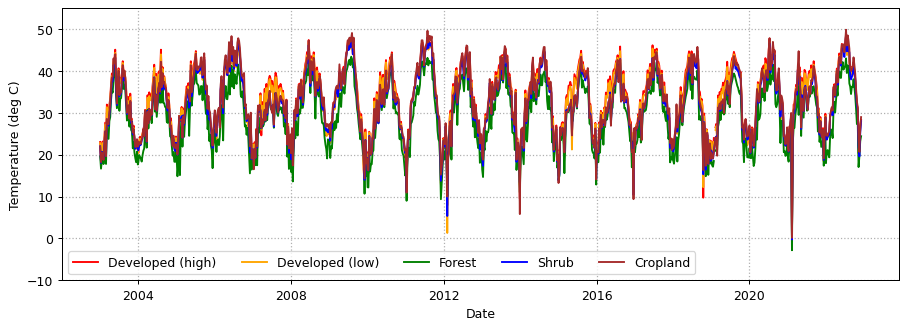

In [510]:
plt.subplots(1,1,figsize=(12,4), dpi = 90)
plt.plot(df['date'], df['temp_dhi']-273.15, label = "Developed (high)", color = "r")
plt.plot(df['date'], df['temp_dlo']-273.15, label = "Developed (low)", color = "orange")
plt.plot(df['date'], df['temp_for']-273.15, label = "Forest", color = "g")
plt.plot(df['date'], df['temp_shr']-273.15, label = "Shrub", color = "blue")
plt.plot(df['date'], df['temp_cro']-273.15, label = "Cropland", color = "brown")
# plt.plot(df['date'], df['temp_wet'], label = "Wetland", color = "blue")

plt.grid(ls = ":", lw = 1)
plt.xlabel("Date")
plt.legend(ncol = 5)
plt.ylabel("Temperature (deg C)")
plt.ylim(-10, 55)

(-8.0, 8.0)

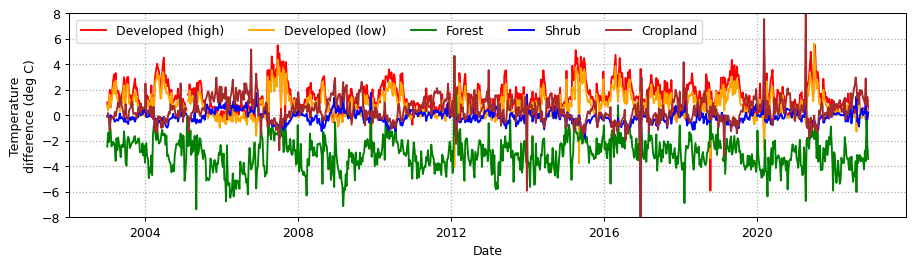

In [511]:
plt.subplots(1,1,figsize=(12,3), dpi = 90)
plt.plot(df['date'], df['temp_dhi'] - df['temp'], label = "Developed (high)", color = "r")
plt.plot(df['date'], df['temp_dlo'] - df['temp'], label = "Developed (low)", color = "orange")
plt.plot(df['date'], df['temp_for'] - df['temp'], label = "Forest", color = "g")
plt.plot(df['date'], df['temp_shr'] - df['temp'], label = "Shrub", color = "blue")
plt.plot(df['date'], df['temp_cro'] - df['temp'], label = "Cropland", color = "brown")
# plt.plot(df['date'], df['temp_wet'] - df['temp'], label = "Wetland", color = "blue")

plt.grid(ls = ":", lw = 1)
plt.xlabel("Date")
plt.legend(ncol = 5)
plt.ylabel("Temperature\ndifference (deg C)")
plt.ylim(-8, 8)

(-10.0, 55.0)

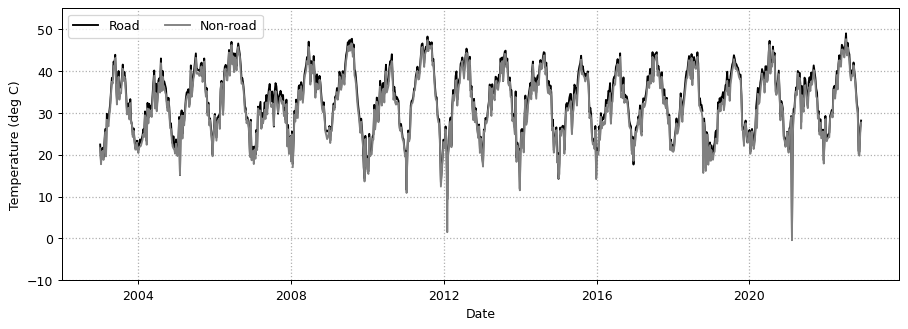

In [512]:
plt.subplots(1,1,figsize=(12,4), dpi = 90)
plt.plot(df['date'], df['temp_rd']-273.15, label = "Road", color = "k")
plt.plot(df['date'], df['temp_nrd']-273.15, label = "Non-road", color = "gray")
# plt.plot(df['date'], df['temp_wet'], label = "Wetland", color = "blue")

plt.grid(ls = ":", lw = 1)
plt.xlabel("Date")
plt.legend(ncol = 2)
plt.ylabel("Temperature (deg C)")
plt.ylim(-10, 55)

(-8.0, 8.0)

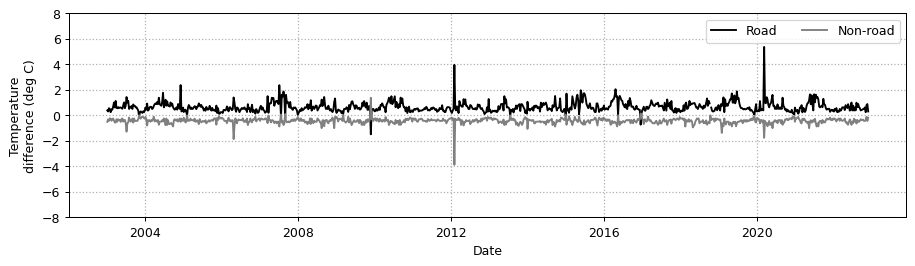

In [513]:
plt.subplots(1,1,figsize=(12,3), dpi = 90)
plt.plot(df['date'], df['temp_rd'] - df['temp'], label = "Road", color = "k")
plt.plot(df['date'], df['temp_nrd'] - df['temp'], label = "Non-road", color = "gray")

plt.grid(ls = ":", lw = 1)
plt.xlabel("Date")
plt.legend(ncol = 2)
plt.ylabel("Temperature\ndifference (deg C)")
plt.ylim(-8, 8)

Text(0.5, 1.0, 'Annual')

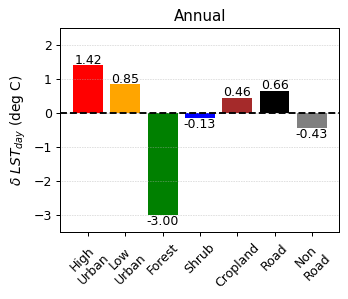

In [466]:
def addlabels(x,y):
    for i in range(len(x)):
        if y[i] >= 0:
            plt.text(i, y[i]+0.05, "{0:.2f}".format(y[i]), ha = 'center')
        else:
            plt.text(i, y[i], "{0:.2f}".format(y[i]), ha = 'center', va = "top")

idx = (df["month"] >= 0) & (df["month"] <= 12) # Total

plt.subplots(1,1,figsize=(4,3), dpi = 90)

mean_temp = {
    'High Urban': (df['temp_dhi'][idx] - df['temp'][idx]).mean(),
    'Low Urban': (df['temp_dlo'][idx] - df['temp'][idx]).mean(),
    'Forest': (df['temp_for'][idx] - df['temp'][idx]).mean(),
    'Shrub': (df['temp_shr'][idx] - df['temp'][idx]).mean(),
    'Cropland': (df['temp_cro'][idx] - df['temp'][idx]).mean(),
    'Road': (df['temp_rd'][idx] - df['temp'][idx]).mean(),
    'Non Road': (df['temp_nrd'][idx] - df['temp'][idx]).mean()
}

xlabels = [s.replace(" ", "\n") for s in mean_temp.keys()]
colors = ["red", 'orange', 'g', 'blue', 'brown', 'k', 'gray']

plt.bar(xlabels, mean_temp.values(), color = colors)
addlabels(xlabels, list(mean_temp.values()))
plt.xticks(rotation = 45)
plt.axhline(0, color = "k", ls = "--")
plt.grid(ls = ":", lw = 0.5, axis = "y")
plt.ylabel("$\delta$ $LST_{day}$ (deg C)", fontsize = 11)
plt.ylim(-3.5, 2.5)
plt.title("Annual")

Text(0.5, 1.0, 'Summer')

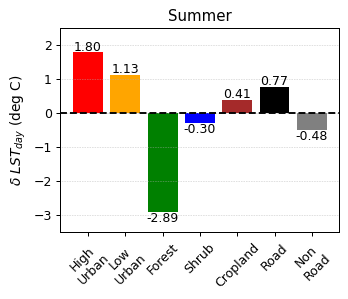

In [467]:
idx = (df["month"] >= 6) & (df["month"] <= 8) # Summer

plt.subplots(1,1,figsize=(4,3), dpi = 90)

mean_temp = {
    'High Urban': (df['temp_dhi'][idx] - df['temp'][idx]).mean(),
    'Low Urban': (df['temp_dlo'][idx] - df['temp'][idx]).mean(),
    'Forest': (df['temp_for'][idx] - df['temp'][idx]).mean(),
    'Shrub': (df['temp_shr'][idx] - df['temp'][idx]).mean(),
    'Cropland': (df['temp_cro'][idx] - df['temp'][idx]).mean(),
    'Road': (df['temp_rd'][idx] - df['temp'][idx]).mean(),
    'Non Road': (df['temp_nrd'][idx] - df['temp'][idx]).mean()
}

xlabels = [s.replace(" ", "\n") for s in mean_temp.keys()]
colors = ["red", 'orange', 'g', 'blue', 'brown', 'k', 'gray']

plt.bar(xlabels, mean_temp.values(), color = colors)
addlabels(xlabels, list(mean_temp.values()))
plt.xticks(rotation = 45)
plt.axhline(0, color = "k", ls = "--")
plt.grid(ls = ":", lw = 0.5, axis = "y")
plt.ylabel("$\delta$ $LST_{day}$ (deg C)", fontsize = 11)
plt.ylim(-3.5, 2.5)
plt.title("Summer")

Text(0.5, 1.0, 'Winter')

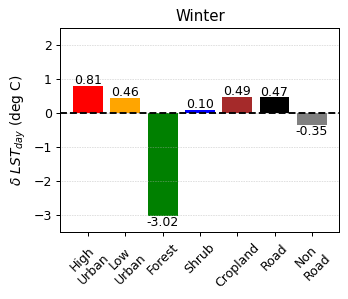

In [468]:
idx = (df["month"] <= 2) | (df["month"] >= 12) # Winter

plt.subplots(1,1,figsize=(4,3), dpi = 90)

mean_temp = {
    'High Urban': (df['temp_dhi'][idx] - df['temp'][idx]).mean(),
    'Low Urban': (df['temp_dlo'][idx] - df['temp'][idx]).mean(),
    'Forest': (df['temp_for'][idx] - df['temp'][idx]).mean(),
    'Shrub': (df['temp_shr'][idx] - df['temp'][idx]).mean(),
    'Cropland': (df['temp_cro'][idx] - df['temp'][idx]).mean(),
    'Road': (df['temp_rd'][idx] - df['temp'][idx]).mean(),
    'Non Road': (df['temp_nrd'][idx] - df['temp'][idx]).mean()
}

xlabels = [s.replace(" ", "\n") for s in mean_temp.keys()]
colors = ["red", 'orange', 'g', 'blue', 'brown', 'k', 'gray']

plt.bar(xlabels, mean_temp.values(), color = colors)
addlabels(xlabels, list(mean_temp.values()))
plt.xticks(rotation = 45)
plt.axhline(0, color = "k", ls = "--")
plt.grid(ls = ":", lw = 0.5, axis = "y")
plt.ylabel("$\delta$ $LST_{day}$ (deg C)", fontsize = 11)
plt.ylim(-3.5, 2.5)
plt.title("Winter")

In [537]:
df

,date,temp,month,year,temp_dhi,temp_dlo,temp_for,temp_shr,temp_cro,temp_wet,temp_rd,temp_nrd
0,2003-01-01,295.225166,1,2003,296.231774,295.942149,292.769059,295.169724,295.112330,295.387122,295.609600,294.718177
1,2003-01-09,291.224455,1,2003,291.772071,291.604820,289.842528,291.219717,291.398678,291.580000,291.527861,290.902231
2,2003-01-17,293.896883,1,2003,295.025495,294.957851,291.800000,293.840700,293.656919,294.300000,294.457248,293.458946
3,2003-01-25,294.340033,1,2003,296.338296,295.955803,293.782683,293.461119,293.150417,293.277825,294.835993,294.104653
4,2003-02-02,292.188526,2,2003,292.812034,292.811655,290.940855,292.197255,291.923462,292.709080,292.433712,291.924725
...,...,...,...,...,...,...,...,...,...,...,...,...
910,2022-11-01,303.599945,11,2022,304.158856,304.021768,300.839544,303.777398,304.526250,304.200882,304.221872,303.159718
911,2022-11-09,293.810021,11,2022,293.603537,293.424902,290.218057,294.937638,296.702981,294.465393,294.054860,293.426210
912,2022-11-17,293.053846,11,2022,293.980000,293.600000,292.834368,292.780000,293.860000,NaN,293.860000,292.936374
913,2022-11-25,298.781111,11,2022,300.222994,299.339614,296.399900,298.462802,299.834654,298.768571,299.663133,298.337362


In [460]:
# Entire Bexar county time series

# Annual changes of Land cover =========================================
nlcd = ee.ImageCollection("USGS/NLCD_RELEASES/2019_REL/NLCD")
year1 = np.array([2001, 2004, 2006, 2008, 2011, 2013, 2016, 2019])
df_lc = pd.DataFrame({})

for y in tqdm(year1):
    landcover = nlcd.filter(ee.Filter.eq('system:index', str(y))).first().select('landcover');  
    
    urban = landcover.expression("b('landcover') > 20 & b('landcover') < 30")
    green = landcover.expression("b('landcover') > 40 & b('landcover') < 50")
    
    total = landcover.reduceRegion(reducer = ee.Reducer.count(), geometry = Bexar, scale = 30)
    urban = landcover.updateMask(urban).reduceRegion(reducer = ee.Reducer.count(), geometry = Bexar, scale = 30)
    green = landcover.updateMask(green).reduceRegion(reducer = ee.Reducer.count(), geometry = Bexar, scale = 30)
    
    df_lc.loc[y, 'pix_total'] = total.getInfo()['landcover']
    df_lc.loc[y, 'pix_urban'] = urban.getInfo()['landcover']
    df_lc.loc[y, 'pix_green'] = green.getInfo()['landcover']

df_lc['fr_urban'] = df_lc['pix_urban'] / df_lc['pix_total'] * 100
df_lc['fr_green'] = df_lc['pix_green'] / df_lc['pix_total'] * 100
print("DONE")

# Annual changes of LST =========================================
df_temp = pd.DataFrame({})

for field in ['LST_Day_1km', 'LST_Night_1km']:
    print(field)
    col = ee.ImageCollection("MODIS/061/MYD11A2").select(field).filterDate('2000-01-01', '2023-01-01')
    year2 = np.arange(2003, 2023)   

    for y in tqdm(year2):
        img = col.filterDate('{0}-01-01'.format(y), '{0}-01-01'.format(y+1)).mean() # annual mean
        img_sum = col.filterDate('{0}-06-01'.format(y), '{0}-09-01'.format(y)).mean() # summer mean
        img_win = col.filterDate('{0}-01-01'.format(y-1), '{0}-02-01'.format(y)).mean() # winter mean

        tmp = img.reduceRegion(reducer = ee.Reducer.mean(), geometry = Bexar, scale = 1000)
        tmp_sum = img_sum.reduceRegion(reducer = ee.Reducer.mean(), geometry = Bexar, scale = 1000)
        tmp_win = img_win.reduceRegion(reducer = ee.Reducer.mean(), geometry = Bexar, scale = 1000)

        df_temp.loc[y, field]  = tmp.getInfo()[field]*0.02 - 273.15
        df_temp.loc[y, field + '_sum']  = tmp_sum.getInfo()[field]*0.02 - 273.15
        df_temp.loc[y, field + '_win']  = tmp_win.getInfo()[field]*0.02 - 273.15

print("DONE")

100%|██████████| 8/8 [00:04<00:00,  1.86it/s]


DONE
LST_Day_1km


100%|██████████| 20/20 [00:10<00:00,  1.98it/s]


LST_Night_1km


100%|██████████| 20/20 [00:10<00:00,  1.94it/s]

DONE


In [461]:
df_temp

,LST_Day_1km,LST_Day_1km_sum,LST_Day_1km_win,LST_Night_1km,LST_Night_1km_sum,LST_Night_1km_win
2003,30.452707,37.166210,27.979462,13.324027,21.423629,12.779751
2004,30.138600,36.444101,29.879085,13.724954,21.355713,12.670016
2005,32.861922,39.846665,29.496052,14.477612,21.922617,13.175200
2006,34.761035,43.163503,32.340822,14.175941,22.097260,13.759597
2007,29.604371,34.139818,33.653158,13.128544,20.177785,13.232713
2008,33.579674,40.612050,28.842438,12.482969,21.314357,12.196820
2009,33.811490,44.434217,32.868539,13.840632,22.313313,11.717478
2010,30.429298,38.510001,32.534597,12.901274,21.890401,12.774771
2011,34.855124,45.007555,29.506595,13.992243,23.032087,12.091767
2012,32.737711,41.172942,33.891304,14.632289,22.358444,13.280201


In [485]:
value1

array([30.45270652, 30.13860043, 32.86192237, 34.76103486, 29.60437088,
       33.5796736 , 33.81148966, 30.4292984 , 34.8551241 , 32.73771071,
       32.68821969, 32.82567366, 31.3679697 , 31.33273499, 33.2945879 ,
       31.91175618, 31.86128576, 33.15485114, 31.88714173, 35.88860554])

(2000.0, 2023.0)

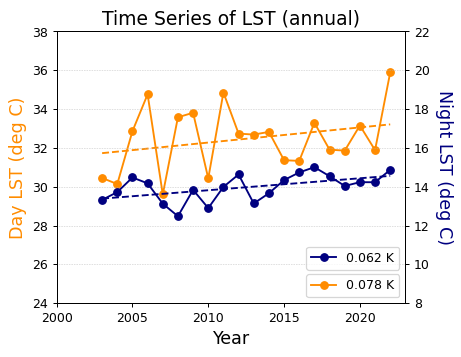

In [594]:
def estimate_coef(x, y):
    # number of observations/points
    n = np.size(x)
  
    # mean of x and y vector
    m_x = np.mean(x)
    m_y = np.mean(y)
  
    # calculating cross-deviation and deviation about x
    SS_xy = np.sum(y*x) - n*m_y*m_x
    SS_xx = np.sum(x*x) - n*m_x*m_x
  
    # calculating regression coefficients
    b_1 = SS_xy / SS_xx
    b_0 = m_y - b_1*m_x
  
    return (b_0, b_1)

value1 = df_temp['LST_Day_1km'].values
value2 = df_temp['LST_Night_1km'].values

b1, a1 = estimate_coef(year2, value1)
b2, a2 = estimate_coef(year2, value2)

# create figure and axis objects with subplots()
fig,ax = plt.subplots(figsize = (5,4), dpi = 90)
# make a plot
ax.plot(year2, value1, color="darkorange", marker="o", label = "{0:.3f} K".format(a1))
ax.plot(year2, a1*year2 + b1,color="darkorange", ls = "--")
# set x-axis label
ax.set_xlabel("Year", fontsize = 14)
# set y-axis label
ax.set_ylabel("Day LST (deg C)", color="darkorange", fontsize=14)
ax.set_ylim(24, 38)

# twin object for two different y-axis on the sample plot
ax2=ax.twinx()
# make a plot with different y-axis using second axis object
ax2.plot(year2, value2, color="navy",marker="o", label = "{0:.3f} K".format(a2))
ax2.plot(year2, a2*year2 + b2,color="navy", ls = "--")
ax2.set_ylabel("Night LST (deg C)",color="navy",fontsize=14, rotation = 270, va = "bottom")
ax2.set_ylim(8, 22)
plt.grid(ls = ":", lw = 0.5)
ax.legend(loc='lower right', bbox_to_anchor=(1,0))
ax2.legend(loc='lower right', bbox_to_anchor=(1,0.1))
plt.title("Time Series of LST (annual)", fontsize = 15)
plt.xlim(2000, 2023)

# plt.savefig("F:\\Heat_Island\\Plot\\Increase_{0}_total.png".format(field),
#            bbox_inches = "tight")

(2000.0, 2023.0)

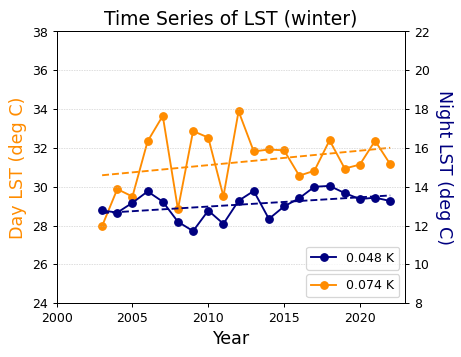

In [591]:
value1 = df_temp['LST_Day_1km' + '_win'].values
value2 = df_temp['LST_Night_1km' + '_win'].values

b1, a1 = estimate_coef(year2, value1)
b2, a2 = estimate_coef(year2, value2)

# create figure and axis objects with subplots()
fig,ax = plt.subplots(figsize = (5,4), dpi = 90)
# make a plot
ax.plot(year2, value1, color="darkorange", marker="o", label = "{0:.3f} K".format(a1))
ax.plot(year2, a1*year2 + b1,color="darkorange", ls = "--")
# set x-axis label
ax.set_xlabel("Year", fontsize = 14)
# set y-axis label
ax.set_ylabel("Day LST (deg C)", color="darkorange", fontsize=14)
ax.set_ylim(24, 38)

# twin object for two different y-axis on the sample plot
ax2=ax.twinx()
# make a plot with different y-axis using second axis object
ax2.plot(year2, value2, color="navy",marker="o", label = "{0:.3f} K".format(a2))
ax2.plot(year2, a2*year2 + b2,color="navy", ls = "--")
ax2.set_ylabel("Night LST (deg C)",color="navy",fontsize=14, rotation = 270, va = "bottom")
ax2.set_ylim(8, 22)
plt.grid(ls = ":", lw = 0.5)
ax.legend(loc='lower right', bbox_to_anchor=(1,0))
ax2.legend(loc='lower right', bbox_to_anchor=(1,0.1))
plt.title("Time Series of LST (winter)", fontsize = 15)
plt.xlim(2000, 2023)

# plt.savefig("F:\\Heat_Island\\Plot\\Increase_{0}_total.png".format(field),
#            bbox_inches = "tight")

(2000.0, 2023.0)

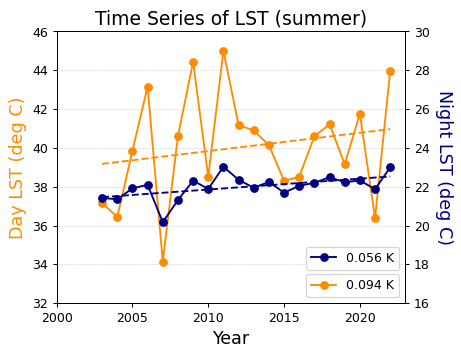

In [587]:
value1 = df_temp['LST_Day_1km' + '_sum'].values
value2 = df_temp['LST_Night_1km' + '_sum'].values

b1, a1 = estimate_coef(year2, value1)
b2, a2 = estimate_coef(year2, value2)

# create figure and axis objects with subplots()
fig,ax = plt.subplots(figsize = (5,4), dpi = 90)
# make a plot
ax.plot(year2, value1, color="darkorange", marker="o", label = "{0:.3f} K".format(a1))
ax.plot(year2, a1*year2 + b1,color="darkorange", ls = "--")
# set x-axis label
ax.set_xlabel("Year", fontsize = 14)
# set y-axis label
ax.set_ylabel("Day LST (deg C)", color="darkorange", fontsize=14)
ax.set_ylim(32, 46)

# twin object for two different y-axis on the sample plot
ax2=ax.twinx()
# make a plot with different y-axis using second axis object
ax2.plot(year2, value2, color="navy",marker="o", label = "{0:.3f} K".format(a2))
ax2.plot(year2, a2*year2 + b2,color="navy", ls = "--")
ax2.set_ylabel("Night LST (deg C)",color="navy",fontsize=14, rotation = 270, va = "bottom")
ax2.set_ylim(16, 30)
plt.grid(ls = ":", lw = 0.5)
ax.legend(loc='lower right', bbox_to_anchor=(1,0))
ax2.legend(loc='lower right', bbox_to_anchor=(1,0.1))
plt.title("Time Series of LST (summer)", fontsize = 15)
plt.xlim(2000, 2023)

# plt.savefig("F:\\Heat_Island\\Plot\\Increase_{0}_total.png".format(field),
#            bbox_inches = "tight")

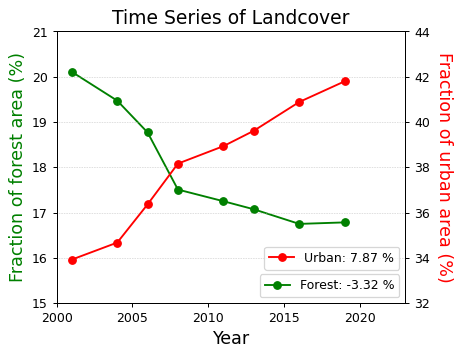

In [506]:
field = 'LST_Day_1km'
value1 = df_lc["fr_green"].values
value2 = df_lc["fr_urban"].values

# b, a = estimate_coef(year2, value2)
# b_sum, a_sum = estimate_coef(year2, value2_sum)
# b_win, a_win = estimate_coef(year2, value2_win)

# create figure and axis objects with subplots()
fig,ax = plt.subplots(figsize = (5,4), dpi = 90)
# make a plot
ax.plot(year1, value1, color="g", marker="o", label = "Forest: {0:.2f} %".format(value1[-1] - value1[0]))
# set x-axis label
ax.set_xlabel("Year", fontsize = 14)
# set y-axis label
ax.set_ylabel("Fraction of forest area (%)", color="g", fontsize=14)
ax.set_ylim(15, 21)

# twin object for two different y-axis on the sample plot
ax2=ax.twinx()
# make a plot with different y-axis using second axis object
ax2.plot(year1, value2, color="r", marker="o", label = "Urban: {0:.2f} %".format(value2[-1] - value2[0]))
ax2.set_ylabel("Fraction of urban area (%)", color="r",fontsize=14, rotation = 270, va = "bottom")
ax2.set_ylim(32, 44)
plt.grid(ls = ":", lw = 0.5)

ax.legend(loc='lower right', bbox_to_anchor=(1,0))
ax2.legend(loc='lower right', bbox_to_anchor=(1,0.1))
plt.title("Time Series of Landcover", fontsize = 15)
plt.xlim(2000, 2023)

plt.savefig("F:\\Heat_Island\\Plot\\Increase_green_{0}_total.png".format(field),
           bbox_inches = "tight")

In [624]:
lc_tract = geemap.ee_to_pandas(tract)

# Annual changes of Land cover =========================================
nlcd = ee.ImageCollection("USGS/NLCD_RELEASES/2019_REL/NLCD")
year1 = np.array([2001, 2004, 2006, 2008, 2011, 2013, 2016, 2019])

for y in tqdm(year1):
    landcover = nlcd.filter(ee.Filter.eq('system:index', str(y))).first().select('landcover');  
    
#     urban = landcover.where(landcover.gt(20).and(landcover.lt(30)))
#     forest = landcover.where(landcover.gt(40).and(landcover.lt(50)))
    urban = landcover.expression("b('landcover') > 20 & b('landcover') < 30")
    green = landcover.expression("b('landcover') > 40 & b('landcover') < 50")
    
    total = landcover.reduceRegions(collection = tract, reducer = ee.Reducer.count(), scale = 30)
    urban = landcover.updateMask(urban).reduceRegions(collection = tract, reducer = ee.Reducer.count(), scale = 30)
    green = landcover.updateMask(green).reduceRegions(collection = tract, reducer = ee.Reducer.count(), scale = 30)
    
    tmp0 = geemap.ee_to_pandas(total)
    tmp1 = geemap.ee_to_pandas(urban)
    tmp2 = geemap.ee_to_pandas(green)
    
    lc_tract['total_{0}'.format(y)]  = tmp0['count'] 
    lc_tract['fr_urban_{0}'.format(y)]  = tmp1['count'] 
    lc_tract['fr_green_{0}'.format(y)]  = tmp2['count']
    
print("DONE")

# Annual changes of LST =========================================
for field in ['LST_Day_1km', 'LST_Night_1km']:
    print(field)

    temp_tract = geemap.ee_to_pandas(tract)
    col = ee.ImageCollection("MODIS/061/MYD11A2").select(field).filterDate('2000-01-01', '2023-01-01')
    year2 = np.arange(2003, 2023)

    for y in tqdm(year2):
        img = col.filterDate('{0}-01-01'.format(y), '{0}-01-01'.format(y+1)).mean() # annual mean
        img_sum = col.filterDate('{0}-06-01'.format(y), '{0}-09-01'.format(y)).mean() # summer mean
        img_win = col.filterDate('{0}-12-01'.format(y-1), '{0}-02-01'.format(y)).mean() # winter mean

        tmp = img.reduceRegions(collection = tract, reducer = ee.Reducer.mean(), scale = 1000)
        tmp_sum = img_sum.reduceRegions(collection = tract, reducer = ee.Reducer.mean(), scale = 1000)
        tmp_win = img_win.reduceRegions(collection = tract, reducer = ee.Reducer.mean(), scale = 1000)

        temp_tract['{0}_{1}'.format(field, y)]  = geemap.ee_to_pandas(tmp)['mean']*0.02
        temp_tract['{0}_sum{1}'.format(field, y)]  = geemap.ee_to_pandas(tmp_sum)['mean']*0.02
        temp_tract['{0}_win{1}'.format(field, y)]  = geemap.ee_to_pandas(tmp_win)['mean']*0.02

    tract_data = lc_tract.join(temp_tract.loc[:,temp_tract.keys()[12:]])
    tract_data.to_csv("F:\\Heat_Island\\{0}_tract_2002-2022.csv".format(field))

    print("DONE")

100%|██████████| 8/8 [00:27<00:00,  3.42s/it]


DONE
LST_Day_1km


100%|██████████| 20/20 [03:55<00:00, 11.78s/it]


DONE
LST_Night_1km


100%|██████████| 20/20 [03:34<00:00, 10.75s/it]

DONE


In [622]:
lc_tract.join(temp_tract.loc[:,temp_tract.keys()[12:]])

,ALAND,AWATER,COUNTYFP,FUNCSTAT,GEOID,INTPTLAT,INTPTLON,MTFCC,NAME,NAMELSAD,...,temp_win2019,temp_2020,temp_sum2020,temp_win2020,temp_2021,temp_sum2021,temp_win2021,temp_2022,temp_sum2022,temp_win2022
0,3428908,13720,029,S,48029110100,+29.4261655,-098.4905264,G5020,1101,Census Tract 1101,...,307.874300,309.125243,318.668594,307.978483,308.460572,315.516579,308.219896,311.383052,320.009945,307.524267
1,1149488,105494,029,S,48029110500,+29.4170710,-098.5090798,G5020,1105,Census Tract 1105,...,307.827562,309.404689,318.627696,308.287613,308.639263,315.038484,308.516743,311.653213,320.731806,307.734478
2,1976489,11034,029,S,48029110600,+29.4292110,-098.5078374,G5020,1106,Census Tract 1106,...,307.718487,309.389393,318.927597,308.307312,308.864647,315.461771,308.482738,311.843973,320.474935,307.905560
3,13443910,12024,029,S,48029120100,+29.4608965,-098.4383400,G5020,1201,Census Tract 1201,...,305.069595,307.079575,315.674789,305.345386,306.241470,312.376970,306.314445,309.924193,318.005844,305.501263
4,6640253,33515,029,S,48029121000,+29.5322204,-098.4454653,G5020,1210,Census Tract 1210,...,305.968021,308.009921,317.538564,306.279922,307.142757,312.418858,307.167955,310.068629,318.788106,306.207244
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
370,3643839,0,029,S,48029191812,+29.6551647,-098.4877610,G5020,1918.12,Census Tract 1918.12,...,303.894723,305.377392,314.469969,304.130355,304.911908,310.484146,304.584227,308.205811,315.884964,304.074514
371,2827853,0,029,S,48029191813,+29.6451452,-098.4994394,G5020,1918.13,Census Tract 1918.13,...,304.281532,305.772350,315.035825,304.621841,305.460380,310.903425,304.978791,308.572779,316.220257,304.660844
372,2549292,0,029,S,48029191815,+29.6295576,-098.5085688,G5020,1918.15,Census Tract 1918.15,...,304.126052,305.774925,315.491242,304.444649,305.325556,311.161179,304.953096,308.170524,315.830896,304.526805
373,1557844,0,029,S,48029980002,+29.3764255,-098.5460439,G5020,9800.02,Census Tract 9800.02,...,307.594175,309.561961,318.868790,307.810744,309.261010,314.685546,308.702894,312.341727,320.405707,308.388040


In [336]:
def estimate_coef(x, y):
    # number of observations/points
    n = np.size(x)
  
    # mean of x and y vector
    m_x = np.mean(x)
    m_y = np.mean(y)
  
    # calculating cross-deviation and deviation about x
    SS_xy = np.sum(y*x) - n*m_y*m_x
    SS_xx = np.sum(x*x) - n*m_x*m_x
  
    # calculating regression coefficients
    b_1 = SS_xy / SS_xx
    b_0 = m_y - b_1*m_x
  
    return (b_0, b_1)

tract_increase = geemap.ee_to_pandas(tract)

for idx in tqdm(range(0, len(lc_tract))):

    value1 = []
    for y in year1:
        value1.append(lc_tract.loc[idx, 'fr_urban_{0}'.format(y)] / lc_tract.loc[idx, 'total_{0}'.format(y)] * 100)

    value2, value2_sum, value2_win = [], [], []
    for y in year2:
        value2.append(temp_tract.loc[idx, 'temp_{0}'.format(y)])
        value2_sum.append(temp_tract.loc[idx, 'temp_sum{0}'.format(y)])
        value2_win.append(temp_tract.loc[idx, 'temp_win{0}'.format(y)])
        
    
    b, a = estimate_coef(year2, value2)
    b_sum, a_sum = estimate_coef(year2, value2_sum)
    b_win, a_win = estimate_coef(year2, value2_win)
    
    tract_increase.loc[idx, "urban"] = value1[-1] - value1[0]
    tract_increase.loc[idx, "LST"] = a
    tract_increase.loc[idx, "LST_sum"] = a_sum
    tract_increase.loc[idx, "LST_win"] = a_win
    
    # create figure and axis objects with subplots()
    fig,ax = plt.subplots()
    # make a plot
    ax.plot(year1, value1, color="red", marker="o", label = "{0:.2f} %".format(value1[-1] - value1[0]))
    # set x-axis label
    ax.set_xlabel("year", fontsize = 14)
    # set y-axis label
    ax.set_ylabel("Fraction of urban area (%)", color="red", fontsize=14)
#     ax.set_ylim(63, 67)

    # twin object for two different y-axis on the sample plot
    ax2=ax.twinx()
    # make a plot with different y-axis using second axis object
    ax2.plot(year2, value2,color="blue",marker="o", label = "{0:.2f} K".format(a))

    
    ax2.plot(year2, a*year2 + b,color="blue", ls = "--")
    ax2.set_ylabel("LST (K)",color="blue",fontsize=14, rotation = 270, va = "bottom")
#     ax2.set_ylim(302, 310)
    plt.grid(ls = ":", lw = 0.5)
    ax.legend(loc='lower right', bbox_to_anchor=(1,0))
    ax2.legend(loc='lower right', bbox_to_anchor=(1,0.1))
    plt.title("TRACT: " + str(temp_tract.loc[idx, "GEOID"]))
    plt.savefig("F:\\Heat_Island\\Plot\\Increase_{0}_{1}.png".format(field, temp_tract.loc[idx, "GEOID"]),
               bbox_inches = "tight")
    plt.close()

tract_increase.to_csv("F:\\Heat_Island\\{0}_increase_SA_2002-2022.csv".format(field))

100%|██████████| 375/375 [01:14<00:00,  5.02it/s]


LST_Day_1km


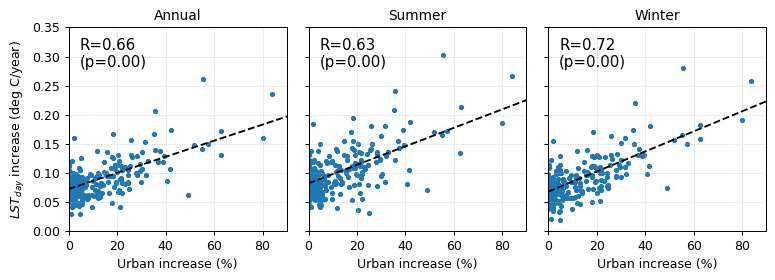

In [540]:
field = 'LST_Day_1km'
print(field)
tract_increase = pd.read_csv("F:\\Heat_Island\\{0}_increase_SA_2002-2022.csv".format(field), index_col = 0)
x = np.arange(0, 100)

fig, ax = plt.subplots(1,3, figsize = (10,3), dpi = 90, sharey = True)
# plt.subplots_adjust(bottom=0.1, right=0.8, top=0.9)
plt.subplots_adjust(wspace=0.1, hspace=0.0)   

r, p = stats.pearsonr(tract_increase["urban"], tract_increase["LST"])
ax[0].scatter(tract_increase["urban"], tract_increase["LST"], s=10, label = "R = {0:.2f}".format(r))
b, a = estimate_coef(tract_increase["urban"], tract_increase["LST"])
ax[0].plot(x, a*x+b, c = "k", ls = "--")
ax[0].set_xlabel("Urban increase (%)")
ax[0].set_ylabel("$LST_{day}$ increase (deg C/year)")
ax[0].set_title("Annual", fontsize = 11)
xmin, xmax = ax[0].set_xlim(0, 90)
ymin, ymax = ax[0].set_ylim(0, 0.35)
# ax[0].legend(loc = "upper left")
ax[0].text(xmin + (xmax-xmin)*0.05, ymax - (ymax-ymin)*0.05, "R={0:.2f}\n(p={1:.2f})".format(r, p),
           va = "top", ha = "left", fontsize = 12)
ax[0].grid(ls = ":", lw = 0.5)

r, p = stats.pearsonr(tract_increase["urban"], tract_increase["LST_sum"])
ax[1].scatter(tract_increase["urban"], tract_increase["LST_sum"], s=10, label = "R = {0:.2f}".format(r))
b, a = estimate_coef(tract_increase["urban"], tract_increase["LST_sum"])
ax[1].plot(x, a*x+b, c = "k", ls = "--")
ax[1].set_xlabel("Urban increase (%)")
ax[1].set_title("Summer", fontsize = 11)
xmin, xmax = ax[1].set_xlim(0, 90)
ymin, ymax = ax[1].set_ylim(0, 0.35)
# ax[1].legend(loc = "upper left")
ax[1].text(xmin + (xmax-xmin)*0.05, ymax - (ymax-ymin)*0.05, "R={0:.2f}\n(p={1:.2f})".format(r, p),
           va = "top", ha = "left", fontsize = 12)
ax[1].grid(ls = ":", lw = 0.5)

r, p = stats.pearsonr(tract_increase["urban"], tract_increase["LST_win"])
ax[2].scatter(tract_increase["urban"], tract_increase["LST_win"], s=10, label = "R = {0:.2f}".format(r))
b, a = estimate_coef(tract_increase["urban"], tract_increase["LST_win"])
ax[2].plot(x, a*x+b, c = "k", ls = "--")
ax[2].set_xlabel("Urban increase (%)")
ax[2].set_title("Winter", fontsize = 11)
xmin, xmax = ax[2].set_xlim(0, 90)
ymin, ymax = ax[2].set_ylim(0, 0.35)
# ax[2].legend(loc = "upper left")
ax[2].text(xmin + (xmax-xmin)*0.05, ymax - (ymax-ymin)*0.05, "R={0:.2f}\n(p={1:.2f})".format(r, p),
           va = "top", ha = "left", fontsize = 12)
plt.grid(ls = ":", lw = 0.5)

In [334]:
print(np.corrcoef(tract_increase["urban"], tract_increase["LST"]))
print(np.corrcoef(tract_increase["urban"], tract_increase["LST_sum"]))
print(np.corrcoef(tract_increase["urban"], tract_increase["LST_win"]))

[[1.         0.32824105]
 [0.32824105 1.        ]]
[[1.         0.52241955]
 [0.52241955 1.        ]]
[[1.         0.24427476]
 [0.24427476 1.        ]]


In [237]:
tract_increase.sort_values("urban")

,ALAND,AWATER,COUNTYFP,FUNCSTAT,GEOID,INTPTLAT,INTPTLON,MTFCC,NAME,NAMELSAD,STATEFP,TRACTCE,urban,LST
296,1338553,0,029,S,48029150502,+29.3717614,-098.5254764,G5020,1505.02,Census Tract 1505.02,48,150502,-0.066979,0.085191
2,1976489,11034,029,S,48029110600,+29.4292110,-098.5078374,G5020,1106,Census Tract 1106,48,110600,-0.045351,0.069727
259,2181682,0,029,S,48029180400,+29.4626758,-098.5708715,G5020,1804,Census Tract 1804,48,180400,-0.041254,0.077704
36,3534331,4030,029,S,48029181100,+29.5263791,-098.5502751,G5020,1811,Census Tract 1811,48,181100,-0.025419,0.059853
192,1109505,27139,029,S,48029190501,+29.4603679,-098.5198886,G5020,1905.01,Census Tract 1905.01,48,190501,0.000000,0.078099
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
130,2071053,1377,029,S,48029171919,+29.3915743,-098.6850980,G5020,1719.19,Census Tract 1719.19,48,171919,57.335069,0.149869
165,6757288,9136,029,S,48029181726,+29.5312744,-098.6945613,G5020,1817.26,Census Tract 1817.26,48,181726,62.659574,0.130895
166,8696577,46627,029,S,48029181729,+29.5261089,-098.7445249,G5020,1817.29,Census Tract 1817.29,48,181729,62.772746,0.172140
168,2752469,2369,029,S,48029181733,+29.5133501,-098.7135103,G5020,1817.33,Census Tract 1817.33,48,181733,80.065359,0.160663


In [210]:
def estimate_coef(x, y):
    # number of observations/points
    n = np.size(x)
  
    # mean of x and y vector
    m_x = np.mean(x)
    m_y = np.mean(y)
  
    # calculating cross-deviation and deviation about x
    SS_xy = np.sum(y*x) - n*m_y*m_x
    SS_xx = np.sum(x*x) - n*m_x*m_x
  
    # calculating regression coefficients
    b_1 = SS_xy / SS_xx
    b_0 = m_y - b_1*m_x
  
    return (b_0, b_1)

Text(0.5, 1.0, 'TRACT: 48029131200')

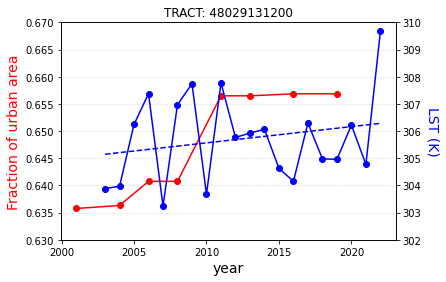

In [219]:
# create figure and axis objects with subplots()
fig,ax = plt.subplots()
# make a plot
ax.plot(year1, value1, color="red", marker="o")
# set x-axis label
ax.set_xlabel("year", fontsize = 14)
# set y-axis label
ax.set_ylabel("Fraction of urban area", color="red", fontsize=14)
ax.set_ylim(0.63, 0.67)

# twin object for two different y-axis on the sample plot
ax2=ax.twinx()
# make a plot with different y-axis using second axis object
ax2.plot(year2, value2,color="blue",marker="o")

b, a = estimate_coef(year2, value2)
ax2.plot(year2, a*year2 + b,color="blue", ls = "--")
ax2.set_ylabel("LST (K)",color="blue",fontsize=14, rotation = 270, va = "bottom")
ax2.set_ylim(302, 310)
plt.grid(ls = ":", lw = 0.5)
plt.title("TRACT: " + str(temp_tract.loc[idx, "GEOID"]))
# plt.show()

# save the plot as a file

# **Time series of *NIGHT* temperature changes (Aqua)**

We will see the temporal changes of surface temperatures around Bexar county area using MODIS temperature data.

Aqua passing time - 1:30 am

In [341]:
field = 'LST_Night_1km'

def create_df_roi(img):
    dt_list = img.reduceColumns(ee.Reducer.toList(2), ['date','temp']).values().get(0)
    df_dt = pd.DataFrame(dt_list.getInfo(), columns=['date', 'temp'])
    df_dt['date'] = pd.to_datetime(df_dt['date'])
    return df_dt

def temp_total(img):
    mean = img.multiply(0.02).reduceRegion(reducer=ee.Reducer.median(), geometry=Bexar, scale=1000).get(field)
    return img.set('date', img.date().format()).set('temp',mean)

def temp_d_high(img):
    mean = img.multiply(0.02).reduceRegion(reducer=ee.Reducer.median(), geometry=d_high, scale=1000).get(field)
    return img.set('date', img.date().format()).set('temp',mean)

def temp_d_low(img):
    mean = img.multiply(0.02).reduceRegion(reducer=ee.Reducer.median(), geometry=d_low, scale=1000).get(field)
    return img.set('date', img.date().format()).set('temp',mean)

def temp_forest(img):
    mean = img.multiply(0.02).reduceRegion(reducer=ee.Reducer.median(), geometry=forest, scale=1000).get(field)
    return img.set('date', img.date().format()).set('temp',mean)

def temp_crops(img):
    mean = img.multiply(0.02).reduceRegion(reducer=ee.Reducer.median(), geometry=crops, scale=1000).get(field)
    return img.set('date', img.date().format()).set('temp',mean)

def temp_shrub(img):
    mean = img.multiply(0.02).reduceRegion(reducer=ee.Reducer.median(), geometry=shrub, scale=1000).get(field)
    return img.set('date', img.date().format()).set('temp',mean)

def temp_wetland(img):
    mean = img.multiply(0.02).reduceRegion(reducer=ee.Reducer.median(), geometry=wetland, scale=1000).get(field)
    return img.set('date', img.date().format()).set('temp',mean)

def temp_road(img):
    mean = img.multiply(0.02).reduceRegion(reducer=ee.Reducer.median(), geometry=road_buf, scale=1000).get(field)
    return img.set('date', img.date().format()).set('temp',mean)

def temp_nroad(img):
    mean = img.multiply(0.02).reduceRegion(reducer=ee.Reducer.median(), geometry=non_road, scale=1000).get(field)
    return img.set('date', img.date().format()).set('temp',mean)

# MODIS Aqua Night data (1:30 am)
col = ee.ImageCollection("MODIS/061/MYD11A2").select(field).filterDate('2000-01-01', '2023-01-01')

img_total = col.map(temp_total)
img_d_high = col.map(temp_d_high)
img_d_low = col.map(temp_d_low)
img_forest = col.map(temp_forest)
img_crops = col.map(temp_crops)
img_shrub = col.map(temp_shrub)
img_wetland = col.map(temp_wetland)
img_road = col.map(temp_road)
img_nroad = col.map(temp_nroad)

# Total temperautre
df = create_df_roi(img_total)
df["month"] = pd.DatetimeIndex(df['date']).month
df["year"] = pd.DatetimeIndex(df['date']).year

# Temperature for each region
df_d_high = create_df_roi(img_d_high)
df_d_low = create_df_roi(img_d_low)
df_forest = create_df_roi(img_forest)
df_crops = create_df_roi(img_crops)
df_shrub = create_df_roi(img_shrub)
df_wetland = create_df_roi(img_wetland)
df_road = create_df_roi(img_road)
df_nroad = create_df_roi(img_nroad)

df = df.join(df_d_high.set_index("date"), on="date", lsuffix='', rsuffix='_dhi')
df = df.join(df_d_low.set_index("date"), on="date", lsuffix='', rsuffix='_dlo')
df = df.join(df_forest.set_index("date"), on="date", lsuffix='', rsuffix='_for')
df = df.join(df_shrub.set_index("date"), on="date", lsuffix='', rsuffix='_shr')
df = df.join(df_crops.set_index("date"), on="date", lsuffix='', rsuffix='_cro')
df = df.join(df_wetland.set_index("date"), on="date", lsuffix='', rsuffix='_wet')
df = df.join(df_road.set_index("date"), on="date", lsuffix='', rsuffix='_rd')
df = df.join(df_nroad.set_index("date"), on="date", lsuffix='', rsuffix='_nrd')

df.to_csv("F:\Heat_Island\{0}_SA_2002-2022.csv".format(field))

df

,date,temp,month,year,temp_dhi,temp_dlo,temp_for,temp_shr,temp_cro,temp_wet,temp_rd,temp_nrd
0,2002-07-04,295.398686,7,2002,295.717577,295.770240,293.890850,295.398312,295.510888,295.660000,295.658091,295.163191
1,2002-07-12,289.683592,7,2002,288.193688,290.433396,285.042903,289.922299,290.170635,291.520229,289.316752,289.931310
2,2002-07-20,295.450352,7,2002,295.610365,295.672330,294.480000,295.451207,295.545870,295.720000,295.671226,295.232737
3,2002-07-28,293.216250,7,2002,291.665537,291.781641,290.269910,293.716432,293.783705,293.278956,293.101619,293.342060
4,2002-08-05,295.330738,8,2002,296.051393,296.109089,294.640000,295.172011,295.218957,295.600000,295.609979,295.140000
...,...,...,...,...,...,...,...,...,...,...,...,...
933,2022-11-01,288.097757,11,2022,288.404200,288.602641,287.328579,287.955362,288.092006,288.607265,288.463026,287.833316
934,2022-11-09,282.186320,11,2022,282.348187,282.444646,281.173700,282.316606,282.196585,282.223251,282.313403,282.065525
935,2022-11-17,278.281338,11,2022,278.341768,278.102240,278.520000,278.285912,278.162751,278.174122,278.223197,278.282955
936,2022-11-25,280.658896,11,2022,280.860000,280.980000,280.666742,280.460590,280.399776,280.611347,280.840499,280.531599


In [469]:
field = 'LST_Night_1km'
df = pd.read_csv("F:\Heat_Island\{0}_SA_2002-2022.csv".format(field), index_col = 0)
df['date'] = pd.to_datetime(df['date'])
df["year"] = pd.DatetimeIndex(df['date']).year
df

,date,temp,month,year,temp_dhi,temp_dlo,temp_for,temp_shr,temp_cro,temp_wet,temp_rd,temp_nrd
0,2002-07-04,295.398686,7,2002,295.717577,295.770240,293.890850,295.398312,295.510888,295.660000,295.658091,295.163191
1,2002-07-12,289.683592,7,2002,288.193688,290.433396,285.042903,289.922299,290.170635,291.520229,289.316752,289.931310
2,2002-07-20,295.450352,7,2002,295.610365,295.672330,294.480000,295.451207,295.545870,295.720000,295.671226,295.232737
3,2002-07-28,293.216250,7,2002,291.665537,291.781641,290.269910,293.716432,293.783705,293.278956,293.101619,293.342060
4,2002-08-05,295.330738,8,2002,296.051393,296.109089,294.640000,295.172011,295.218957,295.600000,295.609979,295.140000
...,...,...,...,...,...,...,...,...,...,...,...,...
933,2022-11-01,288.097757,11,2022,288.404200,288.602641,287.328579,287.955362,288.092006,288.607265,288.463026,287.833316
934,2022-11-09,282.186320,11,2022,282.348187,282.444646,281.173700,282.316606,282.196585,282.223251,282.313403,282.065525
935,2022-11-17,278.281338,11,2022,278.341768,278.102240,278.520000,278.285912,278.162751,278.174122,278.223197,278.282955
936,2022-11-25,280.658896,11,2022,280.860000,280.980000,280.666742,280.460590,280.399776,280.611347,280.840499,280.531599


(-10.0, 55.0)

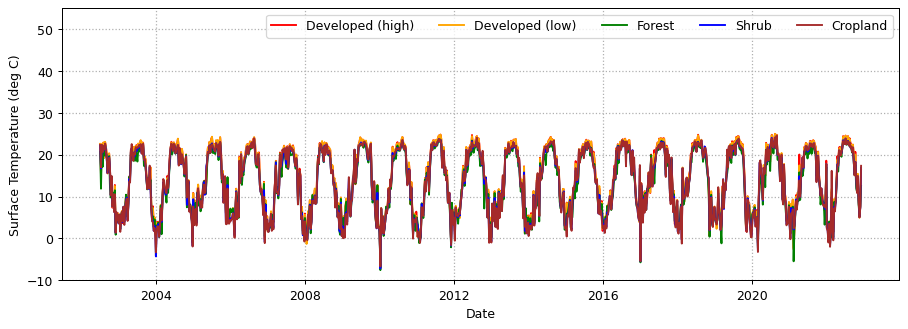

In [350]:
plt.subplots(1,1,figsize=(12,4), dpi = 90)
plt.plot(df['date'], df['temp_dhi']-273.15, label = "Developed (high)", color = "r")
plt.plot(df['date'], df['temp_dlo']-273.15, label = "Developed (low)", color = "orange")
plt.plot(df['date'], df['temp_for']-273.15, label = "Forest", color = "g")
plt.plot(df['date'], df['temp_shr']-273.15, label = "Shrub", color = "blue")
plt.plot(df['date'], df['temp_cro']-273.15, label = "Cropland", color = "brown")
# plt.plot(df['date'], df['temp_wet'], label = "Wetland", color = "blue")

plt.grid(ls = ":", lw = 1)
plt.xlabel("Date")
plt.legend(ncol = 5)
plt.ylabel("Surface Temperature (deg C)")
plt.ylim(-10, 55)

(-8.0, 8.0)

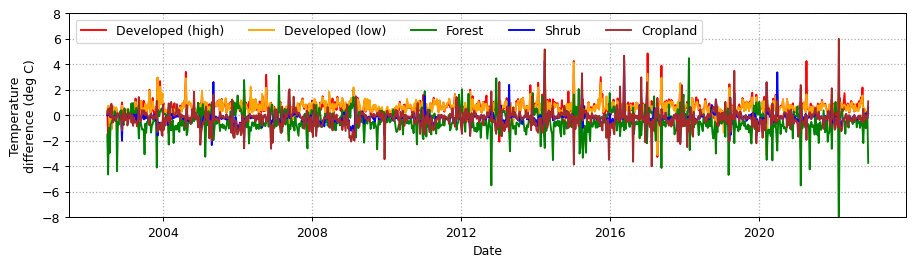

In [351]:
plt.subplots(1,1,figsize=(12,3), dpi = 90)
plt.plot(df['date'], df['temp_dhi'] - df['temp'], label = "Developed (high)", color = "r")
plt.plot(df['date'], df['temp_dlo'] - df['temp'], label = "Developed (low)", color = "orange")
plt.plot(df['date'], df['temp_for'] - df['temp'], label = "Forest", color = "g")
plt.plot(df['date'], df['temp_shr'] - df['temp'], label = "Shrub", color = "blue")
plt.plot(df['date'], df['temp_cro'] - df['temp'], label = "Cropland", color = "brown")
# plt.plot(df['date'], df['temp_wet'] - df['temp'], label = "Wetland", color = "blue")

plt.grid(ls = ":", lw = 1)
plt.xlabel("Date")
plt.legend(ncol = 5)
plt.ylabel("Temperature\ndifference (deg C)")
plt.ylim(-8, 8)

(-10.0, 55.0)

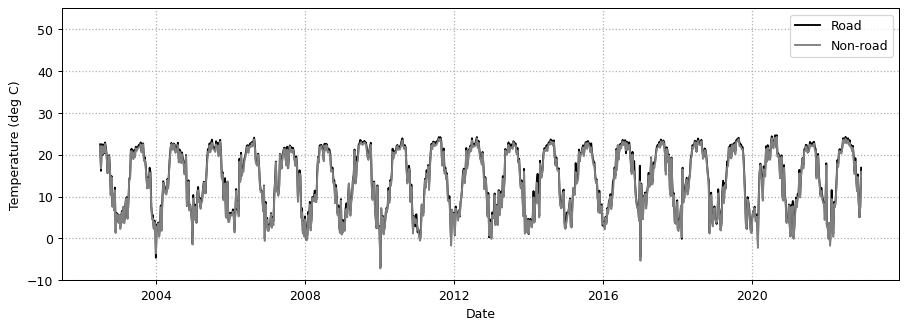

In [352]:
plt.subplots(1,1,figsize=(12,4), dpi = 90)
plt.plot(df['date'], df['temp_rd']-273.15, label = "Road", color = "k")
plt.plot(df['date'], df['temp_nrd']-273.15, label = "Non-road", color = "gray")
# plt.plot(df['date'], df['temp_wet'], label = "Wetland", color = "blue")

plt.grid(ls = ":", lw = 1)
plt.xlabel("Date")
plt.legend()
plt.ylabel("Temperature (deg C)")
plt.ylim(-10, 55)

(-8.0, 8.0)

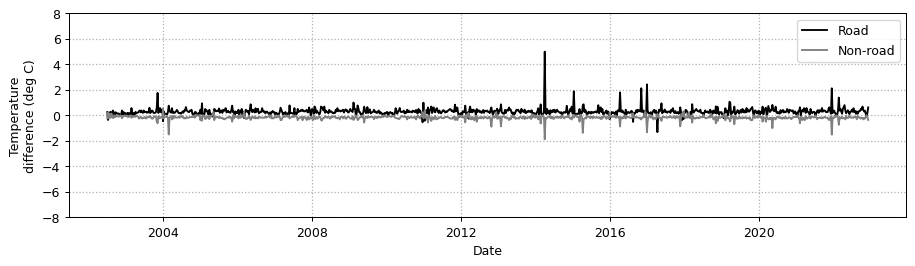

In [353]:
plt.subplots(1,1,figsize=(12,3), dpi = 90)
plt.plot(df['date'], df['temp_rd'] - df['temp'], label = "Road", color = "k")
plt.plot(df['date'], df['temp_nrd'] - df['temp'], label = "Non-road", color = "gray")

plt.grid(ls = ":", lw = 1)
plt.xlabel("Date")
plt.legend()
plt.ylabel("Temperature\ndifference (deg C)")
plt.ylim(-8, 8)

Text(0.5, 1.0, 'Annual')

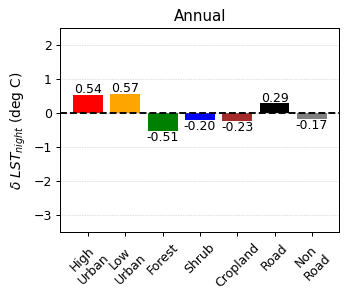

In [470]:
idx = (df["month"] >= 0) & (df["month"] <= 12) # Total

def addlabels(x,y):
    for i in range(len(x)):
        if y[i] >= 0:
            plt.text(i, y[i]+0.05, "{0:.2f}".format(y[i]), ha = 'center')
        else:
            plt.text(i, y[i], "{0:.2f}".format(y[i]), ha = 'center', va = "top")

plt.subplots(1,1,figsize=(4,3), dpi = 90)

mean_temp = {
    'High Urban': (df['temp_dhi'][idx] - df['temp'][idx]).mean(),
    'Low Urban': (df['temp_dlo'][idx] - df['temp'][idx]).mean(),
    'Forest': (df['temp_for'][idx] - df['temp'][idx]).mean(),
    'Shrub': (df['temp_shr'][idx] - df['temp'][idx]).mean(),
    'Cropland': (df['temp_cro'][idx] - df['temp'][idx]).mean(),
    'Road': (df['temp_rd'][idx] - df['temp'][idx]).mean(),
    'Non Road': (df['temp_nrd'][idx] - df['temp'][idx]).mean()
}

xlabels = [s.replace(" ", "\n") for s in mean_temp.keys()]
colors = ["red", 'orange', 'g', 'blue', 'brown', 'k', 'gray']

plt.bar(xlabels, mean_temp.values(), color = colors)
addlabels(xlabels, list(mean_temp.values()))
plt.xticks(rotation = 45)
plt.axhline(0, color = "k", ls = "--")
plt.grid(ls = ":", lw = 0.5, axis = "y")
plt.ylabel("$\delta$ $LST_{night}$ (deg C)", fontsize = 11)
plt.ylim(-3.5, 2.5)
plt.title("Annual")

Text(0.5, 1.0, 'Summer')

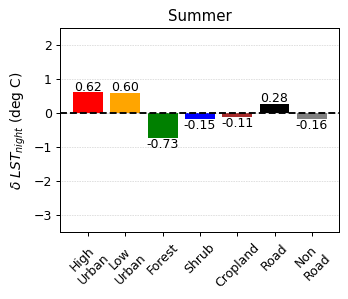

In [473]:
idx = (df["month"] >= 6) & (df["month"] <= 8) # Summer

plt.subplots(1,1,figsize=(4,3), dpi = 90)

mean_temp = {
    'High Urban': (df['temp_dhi'][idx] - df['temp'][idx]).mean(),
    'Low Urban': (df['temp_dlo'][idx] - df['temp'][idx]).mean(),
    'Forest': (df['temp_for'][idx] - df['temp'][idx]).mean(),
    'Shrub': (df['temp_shr'][idx] - df['temp'][idx]).mean(),
    'Cropland': (df['temp_cro'][idx] - df['temp'][idx]).mean(),
    'Road': (df['temp_rd'][idx] - df['temp'][idx]).mean(),
    'Non Road': (df['temp_nrd'][idx] - df['temp'][idx]).mean()
}

xlabels = [s.replace(" ", "\n") for s in mean_temp.keys()]
colors = ["red", 'orange', 'g', 'blue', 'brown', 'k', 'gray']

plt.bar(xlabels, mean_temp.values(), color = colors)
addlabels(xlabels, list(mean_temp.values()))
plt.xticks(rotation = 45)
plt.axhline(0, color = "k", ls = "--")
plt.grid(ls = ":", lw = 0.5, axis = "y")
plt.ylabel("$\delta$ $LST_{night}$ (deg C)", fontsize = 11)
plt.ylim(-3.5, 2.5)
plt.title("Summer")

Text(0.5, 1.0, 'Winter')

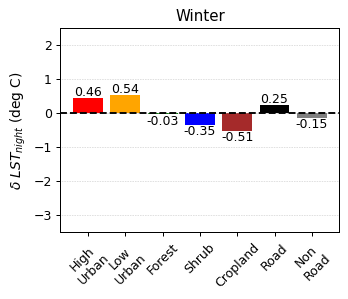

In [474]:
idx = (df["month"] <= 2) | (df["month"] >= 12) # Winter

plt.subplots(1,1,figsize=(4,3), dpi = 90)

mean_temp = {
    'High Urban': (df['temp_dhi'][idx] - df['temp'][idx]).mean(),
    'Low Urban': (df['temp_dlo'][idx] - df['temp'][idx]).mean(),
    'Forest': (df['temp_for'][idx] - df['temp'][idx]).mean(),
    'Shrub': (df['temp_shr'][idx] - df['temp'][idx]).mean(),
    'Cropland': (df['temp_cro'][idx] - df['temp'][idx]).mean(),
    'Road': (df['temp_rd'][idx] - df['temp'][idx]).mean(),
    'Non Road': (df['temp_nrd'][idx] - df['temp'][idx]).mean()
}

xlabels = [s.replace(" ", "\n") for s in mean_temp.keys()]
colors = ["red", 'orange', 'g', 'blue', 'brown', 'k', 'gray']

plt.bar(xlabels, mean_temp.values(), color = colors)
addlabels(xlabels, list(mean_temp.values()))
plt.xticks(rotation = 45)
plt.axhline(0, color = "k", ls = "--")
plt.grid(ls = ":", lw = 0.5, axis = "y")
plt.ylabel("$\delta$ $LST_{night}$ (deg C)", fontsize = 11)
plt.ylim(-3.5, 2.5)
plt.title("Winter")

In [329]:
field = 'LST_Night_1km'
print(field)

lc_tract = geemap.ee_to_pandas(tract)

# Annual changes of Land cover =========================================
nlcd = ee.ImageCollection("USGS/NLCD_RELEASES/2019_REL/NLCD")
year1 = np.array([2001, 2004, 2006, 2008, 2011, 2013, 2016, 2019])

for y in tqdm(year1):
    landcover = nlcd.filter(ee.Filter.eq('system:index', str(y))).first().select('landcover');  
    
#     urban = landcover.where(landcover.gt(20).and(landcover.lt(30)))
#     forest = landcover.where(landcover.gt(40).and(landcover.lt(50)))
    urban = landcover.expression("b('landcover') > 20 & b('landcover') < 30")
    green = landcover.expression("b('landcover') > 40 & b('landcover') < 50")
    
    total = landcover.reduceRegions(collection = tract, reducer = ee.Reducer.count(), scale = 30)
    urban = landcover.updateMask(urban).reduceRegions(collection = tract, reducer = ee.Reducer.count(), scale = 30)
    green = landcover.updateMask(green).reduceRegions(collection = tract, reducer = ee.Reducer.count(), scale = 30)
    
    tmp0 = geemap.ee_to_pandas(total)
    tmp1 = geemap.ee_to_pandas(urban)
    tmp2 = geemap.ee_to_pandas(green)
    
    lc_tract['total_{0}'.format(y)]  = tmp0['count'] 
    lc_tract['fr_urban_{0}'.format(y)]  = tmp1['count'] 
    lc_tract['fr_green_{0}'.format(y)]  = tmp2['count']
    
print("DONE")

# Annual changes of LST =========================================
temp_tract = geemap.ee_to_pandas(tract)
col = ee.ImageCollection("MODIS/061/MYD11A2").select(field).filterDate('2000-01-01', '2023-01-01')
year2 = np.arange(2003, 2023)

for y in tqdm(year2):
    img = col.filterDate('{0}-01-01'.format(y), '{0}-01-01'.format(y+1)).mean() # annual mean
    img_sum = col.filterDate('{0}-06-01'.format(y), '{0}-09-01'.format(y)).mean() # summer mean
    img_win = col.filterDate('{0}-12-01'.format(y-1), '{0}-02-01'.format(y)).mean() # winter mean
    
    tmp = img.reduceRegions(collection = tract, reducer = ee.Reducer.mean(), scale = 1000)
    tmp_sum = img_sum.reduceRegions(collection = tract, reducer = ee.Reducer.mean(), scale = 1000)
    tmp_win = img_win.reduceRegions(collection = tract, reducer = ee.Reducer.mean(), scale = 1000)
    
    temp_tract['temp_{0}'.format(y)]  = geemap.ee_to_pandas(tmp)['mean']*0.02
    temp_tract['temp_sum{0}'.format(y)]  = geemap.ee_to_pandas(tmp_sum)['mean']*0.02
    temp_tract['temp_win{0}'.format(y)]  = geemap.ee_to_pandas(tmp_win)['mean']*0.02

print("DONE")

LST_Night_1km


100%|██████████| 8/8 [00:30<00:00,  3.80s/it]


DONE


100%|██████████| 20/20 [01:19<00:00,  3.99s/it]

DONE


In [330]:
def estimate_coef(x, y):
    # number of observations/points
    n = np.size(x)
  
    # mean of x and y vector
    m_x = np.mean(x)
    m_y = np.mean(y)
  
    # calculating cross-deviation and deviation about x
    SS_xy = np.sum(y*x) - n*m_y*m_x
    SS_xx = np.sum(x*x) - n*m_x*m_x
  
    # calculating regression coefficients
    b_1 = SS_xy / SS_xx
    b_0 = m_y - b_1*m_x
  
    return (b_0, b_1)

tract_increase = geemap.ee_to_pandas(tract)

for idx in tqdm(range(0, len(lc_tract))):

    value1 = []
    for y in years:
        value1.append(lc_tract.loc[idx, 'fr_urban_{0}'.format(y)] / lc_tract.loc[idx, 'total_{0}'.format(y)] * 100)

    value2, value2_sum, value2_win = [], [], []
    for y in range(2003, 2023):
        value2.append(temp_tract.loc[idx, 'temp_{0}'.format(y)])
        value2_sum.append(temp_tract.loc[idx, 'temp_sum{0}'.format(y)])
        value2_win.append(temp_tract.loc[idx, 'temp_win{0}'.format(y)])
        
    
    b, a = estimate_coef(year2, value2)
    b_sum, a_sum = estimate_coef(year2, value2_sum)
    b_win, a_win = estimate_coef(year2, value2_win)
    
    tract_increase.loc[idx, "urban"] = value1[-1] - value1[0]
    tract_increase.loc[idx, "LST"] = a
    tract_increase.loc[idx, "LST_sum"] = a_sum
    tract_increase.loc[idx, "LST_win"] = a_win
    
    # create figure and axis objects with subplots()
    fig,ax = plt.subplots()
    # make a plot
    ax.plot(year1, value1, color="red", marker="o", label = "{0:.2f} %".format(value1[-1] - value1[0]))
    # set x-axis label
    ax.set_xlabel("year", fontsize = 14)
    # set y-axis label
    ax.set_ylabel("Fraction of urban area (%)", color="red", fontsize=14)
#     ax.set_ylim(63, 67)

    # twin object for two different y-axis on the sample plot
    ax2=ax.twinx()
    # make a plot with different y-axis using second axis object
    ax2.plot(year2, value2,color="blue",marker="o", label = "{0:.2f} K".format(a))

    
    ax2.plot(year2, a*year2 + b,color="blue", ls = "--")
    ax2.set_ylabel("LST (K)",color="blue",fontsize=14, rotation = 270, va = "bottom")
#     ax2.set_ylim(302, 310)
    plt.grid(ls = ":", lw = 0.5)
    ax.legend(loc='lower right', bbox_to_anchor=(1,0))
    ax2.legend(loc='lower right', bbox_to_anchor=(1,0.1))
    plt.title("TRACT: " + str(temp_tract.loc[idx, "GEOID"]))
    plt.savefig("F:\\Heat_Island\\Plot\\Increase_{0}_{1}.png".format(field, temp_tract.loc[idx, "GEOID"]),
               bbox_inches = "tight")
    plt.close()

tract_increase.to_csv("F:\\Heat_Island\\{0}_increase_SA_2002-2022.csv".format(field))

100%|██████████| 375/375 [01:16<00:00,  4.90it/s]


LST_Night_1km


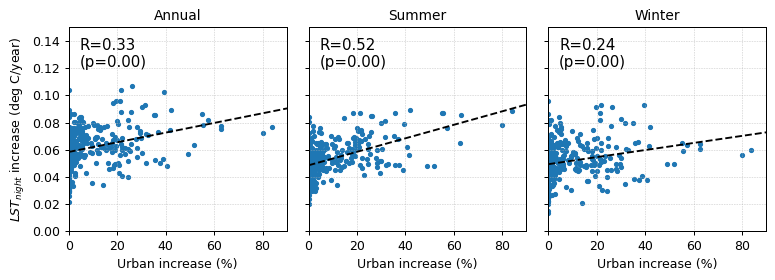

In [537]:
field = 'LST_Night_1km'
print(field)
tract_increase = pd.read_csv("F:\\Heat_Island\\{0}_increase_SA_2002-2022.csv".format(field), index_col = 0)
x = np.arange(0, 100)
fig, ax = plt.subplots(1,3, figsize = (10,3), dpi = 90, sharey = True)
# plt.subplots_adjust(bottom=0.1, right=0.8, top=0.9)
plt.subplots_adjust(wspace=0.1, hspace=0.0)  

r, p = stats.pearsonr(tract_increase["urban"], tract_increase["LST"])
ax[0].scatter(tract_increase["urban"], tract_increase["LST"], s=10, label = "R = {0:.2f}".format(r))
b, a = estimate_coef(tract_increase["urban"], tract_increase["LST"])
ax[0].plot(x, a*x+b, c = "k", ls = "--")
ax[0].set_xlabel("Urban increase (%)")
ax[0].set_ylabel("$LST_{night}$ increase (deg C/year)")
ax[0].set_title("Annual", fontsize = 11)
xmin, xmax = ax[0].set_xlim(0, 90)
ymin, ymax = ax[0].set_ylim(0, 0.15)
# ax[0].legend(loc = "upper left")
ax[0].text(xmin + (xmax-xmin)*0.05, ymax - (ymax-ymin)*0.05, "R={0:.2f}\n(p={1:.2f})".format(r, p),
           va = "top", ha = "left", fontsize = 12)
ax[0].grid(ls = ":", lw = 0.5)

r, p = stats.pearsonr(tract_increase["urban"], tract_increase["LST_sum"])
ax[1].scatter(tract_increase["urban"], tract_increase["LST_sum"], s=10, label = "R = {0:.2f}".format(r))
b, a = estimate_coef(tract_increase["urban"], tract_increase["LST_sum"])
ax[1].plot(x, a*x+b, c = "k", ls = "--")
ax[1].set_xlabel("Urban increase (%)")
ax[1].set_title("Summer", fontsize = 11)
xmin, xmax = ax[1].set_xlim(0, 90)
ymin, ymax = ax[1].set_ylim(0, 0.15)
# ax[1].legend(loc = "upper left")
ax[1].text(xmin + (xmax-xmin)*0.05, ymax - (ymax-ymin)*0.05, "R={0:.2f}\n(p={1:.2f})".format(r, p),
           va = "top", ha = "left", fontsize = 12)
ax[1].grid(ls = ":", lw = 0.5)

r, p = stats.pearsonr(tract_increase["urban"], tract_increase["LST_win"])
ax[2].scatter(tract_increase["urban"], tract_increase["LST_win"], s=10, label = "R = {0:.2f}".format(r))
b, a = estimate_coef(tract_increase["urban"], tract_increase["LST_win"])
ax[2].plot(x, a*x+b, c = "k", ls = "--")
ax[2].set_xlabel("Urban increase (%)")
ax[2].set_title("Winter", fontsize = 11)
xmin, xmax = ax[2].set_xlim(0, 90)
ymin, ymax = ax[2].set_ylim(0, 0.15)
# ax[2].legend(loc = "upper left")
ax[2].text(xmin + (xmax-xmin)*0.05, ymax - (ymax-ymin)*0.05, "R={0:.2f}\n(p={1:.2f})".format(r, p),
           va = "top", ha = "left", fontsize = 12)
plt.grid(ls = ":", lw = 0.5)

In [269]:
temp_tract

,ALAND,AWATER,COUNTYFP,FUNCSTAT,GEOID,INTPTLAT,INTPTLON,MTFCC,NAME,NAMELSAD,...,temp_win2019,temp_2020,temp_sum2020,temp_win2020,temp_2021,temp_sum2021,temp_win2021,temp_2022,temp_sum2022,temp_win2022
0,3428908,13720,029,S,48029110100,+29.4261655,-098.4905264,G5020,1101,Census Tract 1101,...,288.826196,289.750530,289.750530,289.750530,289.288959,289.288959,289.288959,290.105333,290.105333,290.105333
1,1149488,105494,029,S,48029110500,+29.4170710,-098.5090798,G5020,1105,Census Tract 1105,...,288.711847,289.277267,289.277267,289.277267,289.707573,289.707573,289.707573,290.164336,290.164336,290.164336
2,1976489,11034,029,S,48029110600,+29.4292110,-098.5078374,G5020,1106,Census Tract 1106,...,288.825048,289.427387,289.427387,289.427387,289.290009,289.290009,289.290009,290.000915,290.000915,290.000915
3,13443910,12024,029,S,48029120100,+29.4608965,-098.4383400,G5020,1201,Census Tract 1201,...,288.472258,288.298122,288.298122,288.298122,288.815445,288.815445,288.815445,289.163179,289.163179,289.163179
4,6640253,33515,029,S,48029121000,+29.5322204,-098.4454653,G5020,1210,Census Tract 1210,...,288.315002,288.318424,288.318424,288.318424,288.377252,288.377252,288.377252,289.408369,289.408369,289.408369
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
370,3643839,0,029,S,48029191812,+29.6551647,-098.4877610,G5020,1918.12,Census Tract 1918.12,...,286.759559,286.847418,286.847418,286.847418,286.276769,286.276769,286.276769,287.243079,287.243079,287.243079
371,2827853,0,029,S,48029191813,+29.6451452,-098.4994394,G5020,1918.13,Census Tract 1918.13,...,286.859996,286.800017,286.800017,286.800017,286.342140,286.342140,286.342140,287.450259,287.450259,287.450259
372,2549292,0,029,S,48029191815,+29.6295576,-098.5085688,G5020,1918.15,Census Tract 1918.15,...,286.666061,286.577972,286.577972,286.577972,286.594916,286.594916,286.594916,287.871563,287.871563,287.871563
373,1557844,0,029,S,48029980002,+29.3764255,-098.5460439,G5020,9800.02,Census Tract 9800.02,...,288.733017,288.802761,288.802761,288.802761,289.085830,289.085830,289.085830,290.388619,290.388619,290.388619


### Day & Night temp differences

In [357]:
## Add temperature differences
def add_diff(image):
    diff = image.select('LST_Day_1km').subtract(image.select('LST_Night_1km')).rename('LST_diff');
    return image.addBands(diff)

col = ee.ImageCollection("MODIS/061/MYD11A2").filterDate('2000-01-01', '2023-01-01')
withdiff = col.map(add_diff);

In [366]:
field = 'LST_diff'

def create_df_roi(img):
    dt_list = img.reduceColumns(ee.Reducer.toList(2), ['date','temp']).values().get(0)
    df_dt = pd.DataFrame(dt_list.getInfo(), columns=['date', 'temp'])
    df_dt['date'] = pd.to_datetime(df_dt['date'])
    return df_dt

def temp_total(img):
    mean = img.multiply(0.02).reduceRegion(reducer=ee.Reducer.median(), geometry=Bexar, scale=1000).get(field)
    return img.set('date', img.date().format()).set('temp',mean)

def temp_d_high(img):
    mean = img.multiply(0.02).reduceRegion(reducer=ee.Reducer.median(), geometry=d_high, scale=1000).get(field)
    return img.set('date', img.date().format()).set('temp',mean)

def temp_d_low(img):
    mean = img.multiply(0.02).reduceRegion(reducer=ee.Reducer.median(), geometry=d_low, scale=1000).get(field)
    return img.set('date', img.date().format()).set('temp',mean)

def temp_forest(img):
    mean = img.multiply(0.02).reduceRegion(reducer=ee.Reducer.median(), geometry=forest, scale=1000).get(field)
    return img.set('date', img.date().format()).set('temp',mean)

def temp_crops(img):
    mean = img.multiply(0.02).reduceRegion(reducer=ee.Reducer.median(), geometry=crops, scale=1000).get(field)
    return img.set('date', img.date().format()).set('temp',mean)

def temp_shrub(img):
    mean = img.multiply(0.02).reduceRegion(reducer=ee.Reducer.median(), geometry=shrub, scale=1000).get(field)
    return img.set('date', img.date().format()).set('temp',mean)

def temp_wetland(img):
    mean = img.multiply(0.02).reduceRegion(reducer=ee.Reducer.median(), geometry=wetland, scale=1000).get(field)
    return img.set('date', img.date().format()).set('temp',mean)

def temp_road(img):
    mean = img.multiply(0.02).reduceRegion(reducer=ee.Reducer.median(), geometry=road_buf, scale=1000).get(field)
    return img.set('date', img.date().format()).set('temp',mean)

def temp_nroad(img):
    mean = img.multiply(0.02).reduceRegion(reducer=ee.Reducer.median(), geometry=non_road, scale=1000).get(field)
    return img.set('date', img.date().format()).set('temp',mean)

# MODIS Aqua Day data (1:30 pm)
col = withdiff.select(field)

img_total = col.map(temp_total)
img_d_high = col.map(temp_d_high)
img_d_low = col.map(temp_d_low)
img_forest = col.map(temp_forest)
img_crops = col.map(temp_crops)
img_shrub = col.map(temp_shrub)
img_wetland = col.map(temp_wetland)
img_road = col.map(temp_road)
img_nroad = col.map(temp_nroad)

# Total temperautre
df = create_df_roi(img_total)
df["month"] = pd.DatetimeIndex(df['date']).month
df["year"] = pd.DatetimeIndex(df['date']).year

# Temperature for each region
df_d_high = create_df_roi(img_d_high)
df_d_low = create_df_roi(img_d_low)
df_forest = create_df_roi(img_forest)
df_crops = create_df_roi(img_crops)
df_shrub = create_df_roi(img_shrub)
df_wetland = create_df_roi(img_wetland)
df_road = create_df_roi(img_road)
df_nroad = create_df_roi(img_nroad)

df = df.join(df_d_high.set_index("date"), on="date", lsuffix='', rsuffix='_dhi')
df = df.join(df_d_low.set_index("date"), on="date", lsuffix='', rsuffix='_dlo')
df = df.join(df_forest.set_index("date"), on="date", lsuffix='', rsuffix='_for')
df = df.join(df_shrub.set_index("date"), on="date", lsuffix='', rsuffix='_shr')
df = df.join(df_crops.set_index("date"), on="date", lsuffix='', rsuffix='_cro')
df = df.join(df_wetland.set_index("date"), on="date", lsuffix='', rsuffix='_wet')
df = df.join(df_road.set_index("date"), on="date", lsuffix='', rsuffix='_rd')
df = df.join(df_nroad.set_index("date"), on="date", lsuffix='', rsuffix='_nrd')

df.to_csv("F:\\Heat_Island\\{0}_SA_2002-2022.csv".format(field))

df

,date,temp,month,year,temp_dhi,temp_dlo,temp_for,temp_shr,temp_cro,temp_wet,temp_rd,temp_nrd
0,2002-07-04,12.433968,7,2002,14.718977,14.099941,11.163572,12.164587,12.221937,12.209099,13.303441,12.162888
1,2002-07-12,15.351038,7,2002,19.362134,16.198152,17.440000,14.422439,14.201397,14.066388,15.849731,15.125469
2,2002-07-20,12.807627,7,2002,14.894128,14.336837,11.722535,12.336956,12.223892,12.394560,13.564630,12.557001
3,2002-07-28,14.695735,7,2002,18.447705,17.826812,16.535831,13.666351,13.065484,13.832000,15.074075,14.563872
4,2002-08-05,13.187378,8,2002,14.300836,13.699378,10.309951,13.432711,14.690685,13.591042,14.076976,12.685175
...,...,...,...,...,...,...,...,...,...,...,...,...
931,2022-11-01,15.309259,11,2022,15.902207,15.339613,13.340607,15.659487,16.215016,15.360000,15.655983,15.062663
932,2022-11-09,11.810001,11,2022,11.300634,11.427017,9.685407,12.685024,14.176654,12.150394,11.926867,11.571180
933,2022-11-17,15.558182,11,2022,15.880000,15.740000,15.320000,15.280000,NaN,NaN,15.680000,15.553415
934,2022-11-25,18.056270,11,2022,19.162341,18.099252,15.673491,18.193942,19.338882,18.337862,18.396888,17.811948


In [542]:
field = 'LST_diff'
df = pd.read_csv("F:\Heat_Island\{0}_SA_2002-2022.csv".format(field), index_col = 0)
df['date'] = pd.to_datetime(df['date'])
df["year"] = pd.DatetimeIndex(df['date']).year
df

,date,temp,month,year,temp_dhi,temp_dlo,temp_for,temp_shr,temp_cro,temp_wet,temp_rd,temp_nrd
0,2002-07-04,12.433968,7,2002,14.718977,14.099941,11.163572,12.164587,12.221937,12.209099,13.303441,12.162888
1,2002-07-12,15.351038,7,2002,19.362134,16.198152,17.440000,14.422439,14.201397,14.066388,15.849731,15.125469
2,2002-07-20,12.807627,7,2002,14.894128,14.336837,11.722535,12.336956,12.223892,12.394560,13.564630,12.557001
3,2002-07-28,14.695735,7,2002,18.447705,17.826812,16.535831,13.666351,13.065484,13.832000,15.074075,14.563872
4,2002-08-05,13.187378,8,2002,14.300836,13.699378,10.309951,13.432711,14.690685,13.591042,14.076976,12.685175
...,...,...,...,...,...,...,...,...,...,...,...,...
931,2022-11-01,15.309259,11,2022,15.902207,15.339613,13.340607,15.659487,16.215016,15.360000,15.655983,15.062663
932,2022-11-09,11.810001,11,2022,11.300634,11.427017,9.685407,12.685024,14.176654,12.150394,11.926867,11.571180
933,2022-11-17,15.558182,11,2022,15.880000,15.740000,15.320000,15.280000,NaN,NaN,15.680000,15.553415
934,2022-11-25,18.056270,11,2022,19.162341,18.099252,15.673491,18.193942,19.338882,18.337862,18.396888,17.811948


Text(0.5, 1.0, '(a) Annual')

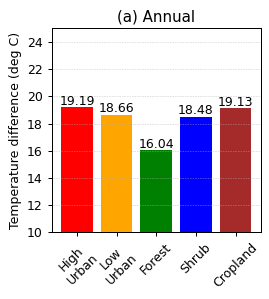

In [550]:
idx = (df["month"] >= 0) & (df["month"] <= 12) # Total

plt.subplots(1,1,figsize=(3,3), dpi = 90)

def addlabels(x,y):
    for i in range(len(x)):
        if y[i] >= 0:
            plt.text(i, y[i]+0.2, "{0:.2f}".format(y[i]), ha = 'center')
        else:
            plt.text(i, y[i], "{0:.2f}".format(y[i]), ha = 'center', va = "top")

mean_temp = {
    'High Urban': (df['temp_dhi'][idx]).mean(),
    'Low Urban': (df['temp_dlo'][idx]).mean(),
    'Forest': (df['temp_for'][idx]).mean(),
    'Shrub': (df['temp_shr'][idx]).mean(),
    'Cropland': (df['temp_cro'][idx]).mean(),
#     'Road': (df['temp_rd'][idx]).mean(),
#     'Non road': (df['temp_nrd'][idx]).mean()
}

xlabels = [s.replace(" ", "\n") for s in mean_temp.keys()]
colors = ["red", 'orange', 'g', 'blue', 'brown', 'k', 'gray']

plt.xticks(rotation = 45)
plt.bar(xlabels, mean_temp.values(), color = colors)
addlabels(xlabels, list(mean_temp.values()))
plt.axhline(0, color = "k", ls = "--")
plt.grid(ls = ":", lw = 0.5, axis = "y")
plt.ylabel("Temperature difference (deg C)")
plt.ylim(10, 25)
plt.title("(a) Annual")

Text(0.5, 1.0, '(b) Summer')

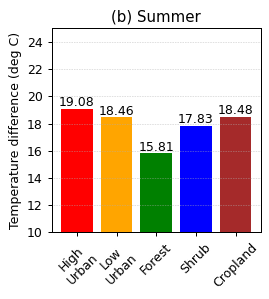

In [551]:
idx = (df["month"] >= 6) & (df["month"] <= 8) # Summer

plt.subplots(1,1,figsize=(3,3), dpi = 90)

mean_temp = {
    'High Urban': (df['temp_dhi'][idx]).mean(),
    'Low Urban': (df['temp_dlo'][idx]).mean(),
    'Forest': (df['temp_for'][idx]).mean(),
    'Shrub': (df['temp_shr'][idx]).mean(),
    'Cropland': (df['temp_cro'][idx]).mean(),
#     'Road': (df['temp_rd'][idx]).mean(),
#     'Non road': (df['temp_nrd'][idx]).mean()
}

xlabels = [s.replace(" ", "\n") for s in mean_temp.keys()]
colors = ["red", 'orange', 'g', 'blue', 'brown', 'k', 'gray']

plt.xticks(rotation = 45)
plt.bar(xlabels, mean_temp.values(), color = colors)
addlabels(xlabels, list(mean_temp.values()))
plt.axhline(0, color = "k", ls = "--")
plt.grid(ls = ":", lw = 0.5, axis = "y")
plt.ylabel("Temperature difference (deg C)")
plt.ylim(10, 25)
plt.title("(b) Summer")

Text(0.5, 1.0, '(c) Winter')

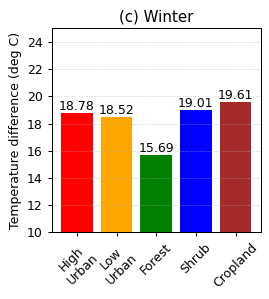

In [549]:
idx = (df["month"] <= 2) | (df["month"] >= 12) # Winter

plt.subplots(1,1,figsize=(3,3), dpi = 90)

mean_temp = {
    'High Urban': (df['temp_dhi'][idx]).mean(),
    'Low Urban': (df['temp_dlo'][idx]).mean(),
    'Forest': (df['temp_for'][idx]).mean(),
    'Shrub': (df['temp_shr'][idx]).mean(),
    'Cropland': (df['temp_cro'][idx]).mean(),
#     'Road': (df['temp_rd'][idx]).mean(),
#     'Non road': (df['temp_nrd'][idx]).mean()
}

xlabels = [s.replace(" ", "\n") for s in mean_temp.keys()]
colors = ["red", 'orange', 'g', 'blue', 'brown', 'k', 'gray']

plt.xticks(rotation = 45)
plt.bar(xlabels, mean_temp.values(), color = colors)
addlabels(xlabels, list(mean_temp.values()))
plt.axhline(0, color = "k", ls = "--")
plt.grid(ls = ":", lw = 0.5, axis = "y")
plt.ylabel("Temperature difference (deg C)")
plt.ylim(10, 25)
plt.title("(c) Winter")

In [422]:
import ee
import geemap

Map = geemap.Map()
Map.centerObject(Bexar, 10)

visParams = {
  'min': 10,
  'max': 25,
  'palette': ['navy', 'blue', 'cyan', 'yellow', 'orange', 'red', 'brown'],
  'opacity': 0.8
};

Map.addLayer(withdiff.select("LST_diff").mean().clip(Bexar).multiply(0.02), visParams, "Day Temperature")


landcover = ee.Image('USGS/NLCD_RELEASES/2019_REL/NLCD/2019').select('landcover')
Map.addLayer(landcover.clip(Bexar), {}, 'NLCD Land Cover')
Map.add_legend(builtin_legend='NLCD')

vis_params = {
    'color': '000000', 
    'pointSize': 3,
    'pointShape': 'circle',
    'width': 1,
    'lineType': 'solid',
    'fillColor': '00000000',
}

Map.addLayer(tract.style(**vis_params), {}, "Styled vector")


Map

Map(center=[29.448823477328762, -98.51996281859623], controls=(WidgetControl(options=['position'], widget=HBox…

### Sociodemographic information

In [706]:
# Demographic data (race)
file = glob.glob("F:\\Heat_Island\\Census\\Demographic\\*-Data.csv")[0]
race = pd.read_csv(file)
race = race.loc[1:, ["GEO_ID", "DP05_0038PE", "DP05_0071PE", "DP05_0077PE"]].reset_index(drop = True)
race = race.rename(columns = {"DP05_0038PE": "black", "DP05_0071PE": "hispanic", "DP05_0077PE": "white"})
for i in range(0, len(race)):
    race.loc[i, "GEOID"] = str(race.loc[i, "GEO_ID"][9:])
    
demo = race.copy()
demo.head()

,GEO_ID,black,hispanic,white,GEOID
0,1400000US48029110100,3.7,56.1,39.3,48029110100
1,1400000US48029110300,1.7,75.2,19.6,48029110300
2,1400000US48029110500,7.1,85.1,5.0,48029110500
3,1400000US48029110600,16.0,63.0,19.2,48029110600
4,1400000US48029110700,3.8,76.5,13.8,48029110700


In [707]:
# Demographic data (age)
file = glob.glob("F:\\Heat_Island\\Census\\Age_and_Sex\\*-Data.csv")[0]
age = pd.read_csv(file)
age = age.loc[1:, ["S0101_C02_030E"]].reset_index(drop = True)
demo["over65"] = age["S0101_C02_030E"].values
demo.head()

,GEO_ID,black,hispanic,white,GEOID,over65
0,1400000US48029110100,3.7,56.1,39.3,48029110100,21.3
1,1400000US48029110300,1.7,75.2,19.6,48029110300,8.3
2,1400000US48029110500,7.1,85.1,5.0,48029110500,11.9
3,1400000US48029110600,16.0,63.0,19.2,48029110600,14.3
4,1400000US48029110700,3.8,76.5,13.8,48029110700,18.3


In [708]:
# Demographic data (income)
file = glob.glob("F:\\Heat_Island\\Census\\income\\*-Data.csv")[0]
income = pd.read_csv(file)
income = income.loc[1:, ["S1901_C01_012E"]].reset_index(drop = True)
demo["income"] = income["S1901_C01_012E"].values
demo.head()

,GEO_ID,black,hispanic,white,GEOID,over65,income
0,1400000US48029110100,3.7,56.1,39.3,48029110100,21.3,48776
1,1400000US48029110300,1.7,75.2,19.6,48029110300,8.3,52456
2,1400000US48029110500,7.1,85.1,5.0,48029110500,11.9,11351
3,1400000US48029110600,16.0,63.0,19.2,48029110600,14.3,16411
4,1400000US48029110700,3.8,76.5,13.8,48029110700,18.3,23646


In [709]:
# Demographic data (insurace)
file = glob.glob("F:\\Heat_Island\\Census\\Health_insurance\\*-Data.csv")[0]
health = pd.read_csv(file)
health = health.loc[1:, ["S2701_C03_001E"]].reset_index(drop = True)
demo["insurance"] = health["S2701_C03_001E"].values
demo.head()

,GEO_ID,black,hispanic,white,GEOID,over65,income,insurance
0,1400000US48029110100,3.7,56.1,39.3,48029110100,21.3,48776,88.9
1,1400000US48029110300,1.7,75.2,19.6,48029110300,8.3,52456,88.2
2,1400000US48029110500,7.1,85.1,5.0,48029110500,11.9,11351,84.1
3,1400000US48029110600,16.0,63.0,19.2,48029110600,14.3,16411,79.2
4,1400000US48029110700,3.8,76.5,13.8,48029110700,18.3,23646,72.7


In [2]:
# Load temperature data

temp_day = pd.read_csv("F:\\Heat_Island\\LST_Day_1km_tract_2002-2022.csv", index_col = 0)
temp_night = pd.read_csv("F:\\Heat_Island\\LST_Night_1km_tract_2002-2022.csv", index_col = 0)
temp_day_diff = pd.read_csv("F:\\Heat_Island\\LST_Day_1km_increase_SA_2002-2022.csv", index_col = 0)
temp_night_diff = pd.read_csv("F:\\Heat_Island\\LST_Night_1km_increase_SA_2002-2022.csv", index_col = 0)
temp_LST = temp_day.join(temp_night.loc[:, temp_night.keys()[36:]])
temp_diff = temp_day_diff.loc[:, ["urban", "LST", "LST_sum", "LST_win"]].join(temp_night_diff.loc[:, ["LST", "LST_sum", "LST_win"]],
                                                                   lsuffix='_Day', rsuffix='_Night')
temp_data = temp_LST.join(temp_diff)
temp_data["GEOID"] = temp_data["GEOID"].astype(str)
data = pd.merge(temp_data, demo, on=["GEOID"])
data.to_csv("F:\\Heat_Island\\Census\\Tract_data.csv")

NameError: name 'demo' is not defined

In [187]:
from scipy import stats

data = pd.read_csv("F:\\Heat_Island\\Census\\Tract_data.csv", index_col = 0)
data = data.replace('-', "0")

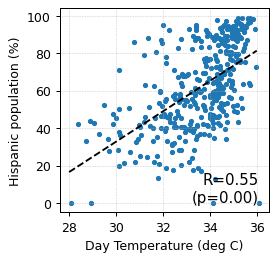

In [192]:
def estimate_coef(x, y):
    # number of observations/points
    n = np.size(x)
  
    # mean of x and y vector
    m_x = np.mean(x)
    m_y = np.mean(y)
  
    # calculating cross-deviation and deviation about x
    SS_xy = np.sum(y*x) - n*m_y*m_x
    SS_xx = np.sum(x*x) - n*m_x*m_x
  
    # calculating regression coefficients
    b_1 = SS_xy / SS_xx
    b_0 = m_y - b_1*m_x
  
    return (b_0, b_1)

field1 = 'LST_Day_1km_2021'
field2 = 'hispanic'

print(field2)
data = pd.read_csv("F:\\Heat_Island\\Census\\Tract_data.csv", index_col = 0)
data = data.replace('-', "0")
x1 = data[field1].astype(float) - 273.15
y1 = data[field2].astype(float)
x = np.arange(int(x1.min()), int(x1.max())+1)
fig, ax = plt.subplots(1,1, figsize = (3,3), dpi = 90, sharey = True)
# plt.subplots_adjust(bottom=0.1, right=0.8, top=0.9)
plt.subplots_adjust(wspace=0.1, hspace=0.0) 

r, p = stats.pearsonr(x1, y1) # np.corrcoef(x1, y1)[0, 1]
ax.scatter(x1, y1, s=10)
b, a = estimate_coef(x1, y1)
ax.plot(x, a*x+b, c = "k", ls = "--")
ax.set_xlabel("Day Temperature (deg C)")
ax.set_ylabel("Hispanic population (%)")
# ax.set_title(, fontsize = 11)
# ax[0].set_xlim(0, 90)
# ax[0].set_ylim(0, 0.4)
# ax.legend()

xmin, xmax = plt.xlim()
ymin, ymax = plt.ylim()

ax.text(xmax - (xmax-xmin)*0.05, ymin + (ymax-ymin)*0.05, "R={0:.2f}\n(p={1:.2f})".format(r, p), ha = "right", fontsize = 12)
ax.grid(ls = ":", lw = 0.5)


black


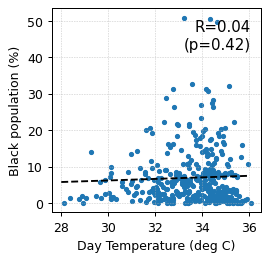

In [210]:
field1 = 'LST_Day_1km_2021'
field2 = 'black'

print(field2)
data = pd.read_csv("F:\\Heat_Island\\Census\\Tract_data.csv", index_col = 0)
data = data.replace('-', "0")
x1 = data[field1].astype(float) - 273.15
y1 = data[field2].astype(float)
x = np.arange(int(x1.min()), int(x1.max())+1)
fig, ax = plt.subplots(1,1, figsize = (3,3), dpi = 90, sharey = True)
# plt.subplots_adjust(bottom=0.1, right=0.8, top=0.9)
plt.subplots_adjust(wspace=0.1, hspace=0.0) 

r, p = stats.pearsonr(x1, y1) # np.corrcoef(x1, y1)[0, 1]
ax.scatter(x1, y1, s=10)
b, a = estimate_coef(x1, y1)
ax.plot(x, a*x+b, c = "k", ls = "--")
ax.set_xlabel("Day Temperature (deg C)")
ax.set_ylabel("Black population (%)")
# ax.set_title(, fontsize = 11)
# ax[0].set_xlim(0, 90)
# ax[0].set_ylim(0, 0.4)
# ax.legend()

xmin, xmax = plt.xlim()
ymin, ymax = plt.ylim()

ax.text(xmax - (xmax-xmin)*0.05, ymax - (ymax-ymin)*0.2, "R={0:.2f}\n(p={1:.2f})".format(r, p), ha = "right", fontsize = 12)
ax.grid(ls = ":", lw = 0.5)


white


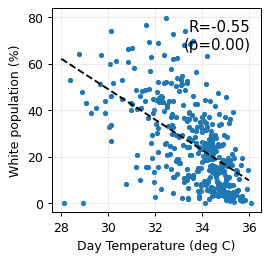

In [202]:
field1 = 'LST_Day_1km_2021'
field2 = 'white'

print(field2)
data = pd.read_csv("F:\\Heat_Island\\Census\\Tract_data.csv", index_col = 0)
data = data.replace('-', "0")
x1 = data[field1].astype(float) - 273.15
y1 = data[field2].astype(float)
x = np.arange(int(x1.min()), int(x1.max())+1)
fig, ax = plt.subplots(1,1, figsize = (3,3), dpi = 90, sharey = True)
# plt.subplots_adjust(bottom=0.1, right=0.8, top=0.9)
plt.subplots_adjust(wspace=0.1, hspace=0.0) 

r, p = stats.pearsonr(x1, y1) # np.corrcoef(x1, y1)[0, 1]
ax.scatter(x1, y1, s=10)
b, a = estimate_coef(x1, y1)
ax.plot(x, a*x+b, c = "k", ls = "--")
ax.set_xlabel("Day Temperature (deg C)")
ax.set_ylabel("White population (%)")
# ax.set_title(, fontsize = 11)
# ax[0].set_xlim(0, 90)
# ax[0].set_ylim(0, 0.4)
# ax.legend()

xmin, xmax = plt.xlim()
ymin, ymax = plt.ylim()

ax.text(xmax - (xmax-xmin)*0.05, ymax - (ymax-ymin)*0.2, "R={0:.2f}\n(p={1:.2f})".format(r, p), ha = "right", fontsize = 12)
ax.grid(ls = ":", lw = 0.5)

income


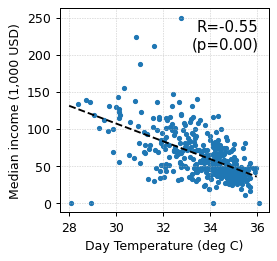

In [204]:
field1 = 'LST_Day_1km_2021'
field2 = 'income'

print(field2)
data = pd.read_csv("F:\\Heat_Island\\Census\\Tract_data.csv", index_col = 0)
data = data.replace('-', "0").replace("250,000+", "250000")
x1 = data[field1].astype(float) - 273.15
y1 = data[field2].astype(float)/1000
x = np.arange(int(x1.min()), int(x1.max())+1)
fig, ax = plt.subplots(1,1, figsize = (3,3), dpi = 90, sharey = True)
# plt.subplots_adjust(bottom=0.1, right=0.8, top=0.9)
plt.subplots_adjust(wspace=0.1, hspace=0.0) 

r, p = stats.pearsonr(x1, y1) # np.corrcoef(x1, y1)[0, 1]
ax.scatter(x1, y1, s=10)
b, a = estimate_coef(x1, y1)
ax.plot(x, a*x+b, c = "k", ls = "--")
ax.set_xlabel("Day Temperature (deg C)")
ax.set_ylabel("Median income (1,000 USD)")
# ax.set_title(, fontsize = 11)
# ax[0].set_xlim(0, 90)
# ax[0].set_ylim(0, 0.4)
# ax.legend()

xmin, xmax = plt.xlim()
ymin, ymax = plt.ylim()

ax.text(xmax - (xmax-xmin)*0.05, ymax - (ymax-ymin)*0.2, "R={0:.2f}\n(p={1:.2f})".format(r, p), ha = "right", fontsize = 12)
ax.grid(ls = ":", lw = 0.5)

over65


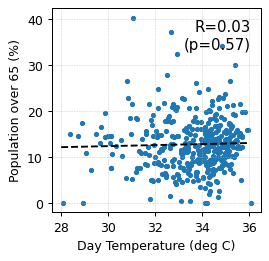

In [209]:
field1 = 'LST_Day_1km_2021'
field2 = 'over65'

print(field2)
data = pd.read_csv("F:\\Heat_Island\\Census\\Tract_data.csv", index_col = 0)
data = data.replace('-', "0").replace("250,000+", "250000")
x1 = data[field1].astype(float) - 273.15
y1 = data[field2].astype(float)
x = np.arange(int(x1.min()), int(x1.max())+1)
fig, ax = plt.subplots(1,1, figsize = (3,3), dpi = 90, sharey = True)
# plt.subplots_adjust(bottom=0.1, right=0.8, top=0.9)
plt.subplots_adjust(wspace=0.1, hspace=0.0) 

r, p = stats.pearsonr(x1, y1) # np.corrcoef(x1, y1)[0, 1]
ax.scatter(x1, y1, s=10)
b, a = estimate_coef(x1, y1)
ax.plot(x, a*x+b, c = "k", ls = "--")
ax.set_xlabel("Day Temperature (deg C)")
ax.set_ylabel("Population over 65 (%)")
# ax.set_title(, fontsize = 11)
# ax[0].set_xlim(0, 90)
# ax[0].set_ylim(0, 0.4)
# ax.legend()

xmin, xmax = plt.xlim()
ymin, ymax = plt.ylim()

ax.text(xmax - (xmax-xmin)*0.05, ymax - (ymax-ymin)*0.2, "R={0:.2f}\n(p={1:.2f})".format(r, p), ha = "right", fontsize = 12)
ax.grid(ls = ":", lw = 0.5)

insurance


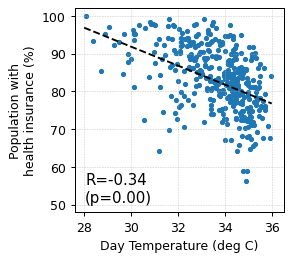

In [208]:
field1 = 'LST_Day_1km_2021'
field2 = 'insurance'

print(field2)
data = pd.read_csv("F:\\Heat_Island\\Census\\Tract_data.csv", index_col = 0)
data = data.replace('-', "0").replace("250,000+", "250000")
x1 = data[field1].astype(float) - 273.15
y1 = data[field2].astype(float)
x = np.arange(int(x1.min()), int(x1.max())+1)
fig, ax = plt.subplots(1,1, figsize = (3,3), dpi = 90, sharey = True)
# plt.subplots_adjust(bottom=0.1, right=0.8, top=0.9)
plt.subplots_adjust(wspace=0.1, hspace=0.0) 

r, p = stats.pearsonr(x1, y1) # np.corrcoef(x1, y1)[0, 1]
ax.scatter(x1, y1, s=10)
b, a = estimate_coef(x1, y1)
ax.plot(x, a*x+b, c = "k", ls = "--")
ax.set_xlabel("Day Temperature (deg C)")
ax.set_ylabel("Population with\nhealth insurance (%)")
# ax.set_title(, fontsize = 11)
# ax[0].set_xlim(0, 90)
ax.set_ylim(48, 102)
# ax.legend()

xmin, xmax = plt.xlim()
ymin, ymax = plt.ylim()

ax.text(xmin + (xmax-xmin)*0.05, ymin + (ymax-ymin)*0.05, "R={0:.2f}\n(p={1:.2f})".format(r, p), ha = "left", fontsize = 12)
ax.grid(ls = ":", lw = 0.5)

## Comparison with other parameters

In [30]:
import rasterio
from rasterio.plot import show
import gdal

In [283]:
folder = "F:\\Heat_Island\\MODIS_LST\\v2\\"
filename = "LSTD"

dataset = gdal.Open(folder + filename + ".tif")
image = dataset.ReadAsArray()
del dataset

LC = image[-1]
LST = image[0] #.flatten()
ET = image[1] #.flatten()
NDVI = image[2] #.flatten()
Alb = image[3] + image[4] #.flatten()

idx_urban = (LC >= 20) & (LC < 30)
idx_forest = (LC >= 40) & (LC < 50)
idx_shrub = (LC >= 50) & (LC < 60)
idx_crop = (LC >= 80) & (LC < 90)

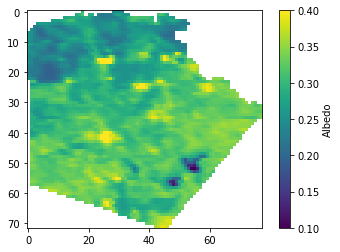

In [286]:
plt.imshow(Alb, vmin = 0.1, vmax = 0.4, cmap = "viridis")
plt.colorbar(label = "Albedo")

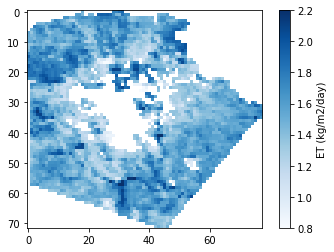

In [251]:
plt.imshow(ET/8, vmin = 0.8, vmax = 2.2, cmap = "Blues")
plt.colorbar(label = "ET (kg/m2/day)")

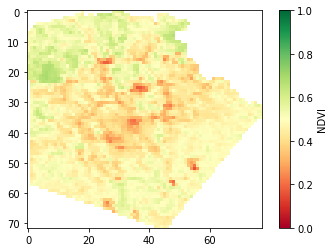

In [252]:
plt.imshow(NDVI, vmin = 0, vmax = 1.0, cmap = "RdYlGn")
plt.colorbar(label = "NDVI")

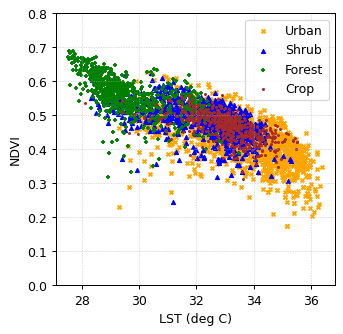

In [253]:
x = LST
y = NDVI

plt.subplots(1,1, figsize = (4,4), dpi = 90)
plt.scatter(x[idx_urban], y[idx_urban], s = 10, color = "orange", marker = "x", label = "Urban")
plt.scatter(x[idx_shrub], y[idx_shrub], s = 10, color = "b", marker = "^", label = "Shrub")
plt.scatter(x[idx_forest], y[idx_forest], s = 10, color = "g", marker = "+", label = "Forest")
plt.scatter(x[idx_crop], y[idx_crop], s = 2, color = "brown", label = "Crop")
plt.xlabel("LST (deg C)")
plt.ylabel("NDVI"); plt.ylim(0,0.8)
plt.grid(ls = ":", lw = 0.5)

plt.legend()
plt.savefig(folder + "Scatter_NDVI_" + filename, bbox_inches = "tight")

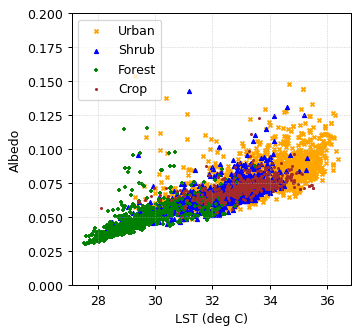

In [256]:
x = LST
y = Alb

plt.subplots(1,1, figsize = (4,4), dpi = 90)
plt.scatter(x[idx_urban], y[idx_urban], s = 10, color = "orange", marker = "x", label = "Urban")
plt.scatter(x[idx_shrub], y[idx_shrub], s = 10, color = "b", marker = "^", label = "Shrub")
plt.scatter(x[idx_forest], y[idx_forest], s = 10, color = "g", marker = "+", label = "Forest")
plt.scatter(x[idx_crop], y[idx_crop], s = 2, color = "brown", label = "Crop")
plt.xlabel("LST (deg C)")
plt.ylabel("Albedo"); plt.ylim(0.0, 0.2)
plt.grid(ls = ":", lw = 0.5)

plt.legend()
plt.savefig(folder + "Scatter_Alb_" + filename, bbox_inches = "tight")

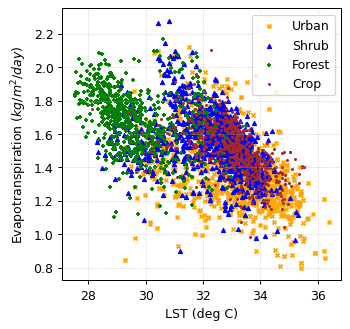

In [257]:
x = LST
y = ET/8

plt.subplots(1,1, figsize = (4,4), dpi = 90)
plt.scatter(x[idx_urban], y[idx_urban], s = 10, color = "orange", marker = "x", label = "Urban")
plt.scatter(x[idx_shrub], y[idx_shrub], s = 10, color = "b", marker = "^", label = "Shrub")
plt.scatter(x[idx_forest], y[idx_forest], s = 10, color = "g", marker = "+", label = "Forest")
plt.scatter(x[idx_crop], y[idx_crop], s = 2, color = "brown", label = "Crop")
plt.xlabel("LST (deg C)")
plt.ylabel("Evapotranspiration $(kg/m^2/day)$"); # plt.ylim(0,0.3)
plt.grid(ls = ":", lw = 0.5)

plt.legend()
plt.savefig(folder + "Scatter_ET_" + filename, bbox_inches = "tight")

In [258]:
folder = "F:\\Heat_Island\\MODIS_LST\\v2\\"
filename = "LSTD_sum"

dataset = gdal.Open(folder + filename + ".tif")
image = dataset.ReadAsArray()
del dataset

LC = image[-1]
LST = image[0] #.flatten()
ET = image[1] #.flatten()
NDVI = image[2] #.flatten()
Alb = image[3] + image[4] #.flatten()

idx_urban = (LC >= 20) & (LC < 30)
idx_forest = (LC >= 40) & (LC < 50)
idx_shrub = (LC >= 50) & (LC < 60)
idx_crop = (LC >= 80) & (LC < 90)

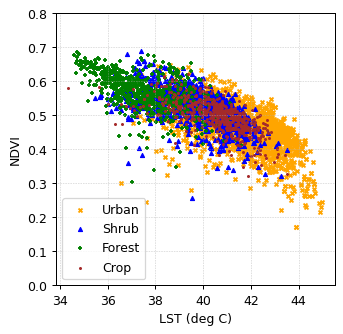

In [259]:
x = LST
y = NDVI

plt.subplots(1,1, figsize = (4,4), dpi = 90)
plt.scatter(x[idx_urban], y[idx_urban], s = 10, color = "orange", marker = "x", label = "Urban")
plt.scatter(x[idx_shrub], y[idx_shrub], s = 10, color = "b", marker = "^", label = "Shrub")
plt.scatter(x[idx_forest], y[idx_forest], s = 10, color = "g", marker = "+", label = "Forest")
plt.scatter(x[idx_crop], y[idx_crop], s = 2, color = "brown", label = "Crop")
plt.xlabel("LST (deg C)")
plt.ylabel("NDVI"); plt.ylim(0,0.8)
plt.grid(ls = ":", lw = 0.5)

plt.legend()
plt.savefig(folder + "Scatter_NDVI_" + filename, bbox_inches = "tight")

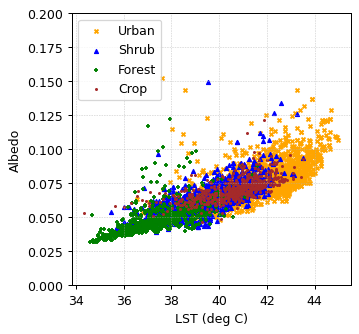

In [261]:
x = LST
y = Alb

plt.subplots(1,1, figsize = (4,4), dpi = 90)
plt.scatter(x[idx_urban], y[idx_urban], s = 10, color = "orange", marker = "x", label = "Urban")
plt.scatter(x[idx_shrub], y[idx_shrub], s = 10, color = "b", marker = "^", label = "Shrub")
plt.scatter(x[idx_forest], y[idx_forest], s = 10, color = "g", marker = "+", label = "Forest")
plt.scatter(x[idx_crop], y[idx_crop], s = 2, color = "brown", label = "Crop")
plt.xlabel("LST (deg C)")
plt.ylabel("Albedo"); plt.ylim(0, 0.2)
plt.grid(ls = ":", lw = 0.5)

plt.legend()
plt.savefig(folder + "Scatter_Alb_" + filename, bbox_inches = "tight")

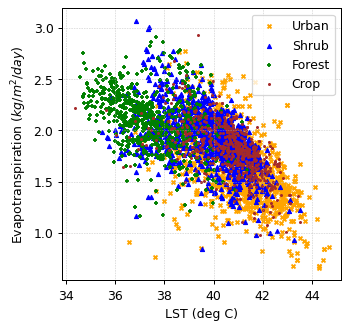

In [262]:
x = LST
y = ET/8

plt.subplots(1,1, figsize = (4,4), dpi = 90)
plt.scatter(x[idx_urban], y[idx_urban], s = 10, color = "orange", marker = "x", label = "Urban")
plt.scatter(x[idx_shrub], y[idx_shrub], s = 10, color = "b", marker = "^", label = "Shrub")
plt.scatter(x[idx_forest], y[idx_forest], s = 10, color = "g", marker = "+", label = "Forest")
plt.scatter(x[idx_crop], y[idx_crop], s = 2, color = "brown", label = "Crop")
plt.xlabel("LST (deg C)")
plt.ylabel("Evapotranspiration $(kg/m^2/day)$"); # plt.ylim(0,0.3)
plt.grid(ls = ":", lw = 0.5)

plt.legend()
plt.savefig(folder + "Scatter_ET_" + filename, bbox_inches = "tight")

In [263]:
folder = "F:\\Heat_Island\\MODIS_LST\\v2\\"
filename = "LSTD_win"

dataset = gdal.Open(folder + filename + ".tif")
image = dataset.ReadAsArray()
del dataset

LC = image[-1]
LST = image[0] #.flatten()
ET = image[1] #.flatten()
NDVI = image[2] #.flatten()
Alb = image[3] + image[4] #.flatten()

idx_urban = (LC >= 20) & (LC < 30)
idx_forest = (LC >= 40) & (LC < 50)
idx_shrub = (LC >= 50) & (LC < 60)
idx_crop = (LC >= 80) & (LC < 90)

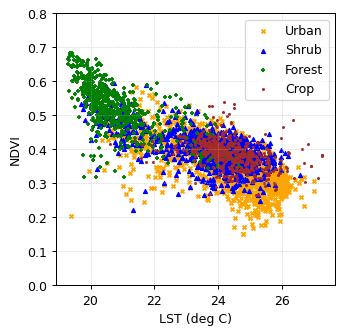

In [264]:
x = LST
y = NDVI

plt.subplots(1,1, figsize = (4,4), dpi = 90)
plt.scatter(x[idx_urban], y[idx_urban], s = 10, color = "orange", marker = "x", label = "Urban")
plt.scatter(x[idx_shrub], y[idx_shrub], s = 10, color = "b", marker = "^", label = "Shrub")
plt.scatter(x[idx_forest], y[idx_forest], s = 10, color = "g", marker = "+", label = "Forest")
plt.scatter(x[idx_crop], y[idx_crop], s = 2, color = "brown", label = "Crop")
plt.xlabel("LST (deg C)")
plt.ylabel("NDVI"); plt.ylim(0,0.8)
plt.grid(ls = ":", lw = 0.5)

plt.legend()
plt.savefig(folder + "Scatter_NDVI_" + filename, bbox_inches = "tight")

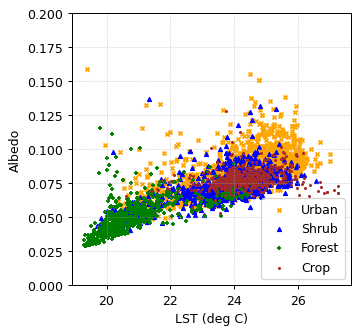

In [265]:
x = LST
y = Alb

plt.subplots(1,1, figsize = (4,4), dpi = 90)
plt.scatter(x[idx_urban], y[idx_urban], s = 10, color = "orange", marker = "x", label = "Urban")
plt.scatter(x[idx_shrub], y[idx_shrub], s = 10, color = "b", marker = "^", label = "Shrub")
plt.scatter(x[idx_forest], y[idx_forest], s = 10, color = "g", marker = "+", label = "Forest")
plt.scatter(x[idx_crop], y[idx_crop], s = 2, color = "brown", label = "Crop")
plt.xlabel("LST (deg C)")
plt.ylabel("Albedo"); plt.ylim(0, 0.2)
plt.grid(ls = ":", lw = 0.5)

plt.legend()
plt.savefig(folder + "Scatter_Alb_" + filename, bbox_inches = "tight")

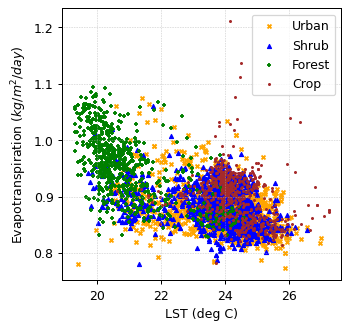

In [266]:
x = LST
y = ET/8

plt.subplots(1,1, figsize = (4,4), dpi = 90)
plt.scatter(x[idx_urban], y[idx_urban], s = 10, color = "orange", marker = "x", label = "Urban")
plt.scatter(x[idx_shrub], y[idx_shrub], s = 10, color = "b", marker = "^", label = "Shrub")
plt.scatter(x[idx_forest], y[idx_forest], s = 10, color = "g", marker = "+", label = "Forest")
plt.scatter(x[idx_crop], y[idx_crop], s = 2, color = "brown", label = "Crop")
plt.xlabel("LST (deg C)")
plt.ylabel("Evapotranspiration $(kg/m^2/day)$"); # plt.ylim(0,0.3)
plt.grid(ls = ":", lw = 0.5)

plt.legend()
plt.savefig(folder + "Scatter_ET_" + filename, bbox_inches = "tight")

In [267]:
folder = "F:\\Heat_Island\\MODIS_LST\\v2\\"
filename = "LSTN"

dataset = gdal.Open(folder + filename + ".tif")
image = dataset.ReadAsArray()
del dataset

LC = image[-1]
LST = image[0] #.flatten()
ET = image[1] #.flatten()
NDVI = image[2] #.flatten()
Alb = image[3] + image[4] #.flatten()

idx_urban = (LC >= 20) & (LC < 30)
idx_forest = (LC >= 40) & (LC < 50)
idx_shrub = (LC >= 50) & (LC < 60)
idx_crop = (LC >= 80) & (LC < 90)

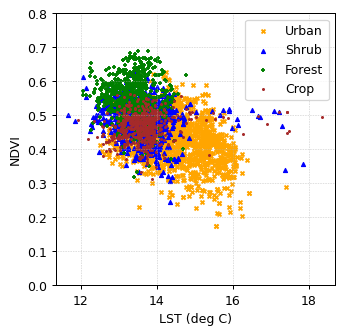

In [268]:
x = LST
y = NDVI

plt.subplots(1,1, figsize = (4,4), dpi = 90)
plt.scatter(x[idx_urban], y[idx_urban], s = 10, color = "orange", marker = "x", label = "Urban")
plt.scatter(x[idx_shrub], y[idx_shrub], s = 10, color = "b", marker = "^", label = "Shrub")
plt.scatter(x[idx_forest], y[idx_forest], s = 10, color = "g", marker = "+", label = "Forest")
plt.scatter(x[idx_crop], y[idx_crop], s = 2, color = "brown", label = "Crop")
plt.xlabel("LST (deg C)")
plt.ylabel("NDVI"); plt.ylim(0,0.8)
plt.grid(ls = ":", lw = 0.5)

plt.legend()
plt.savefig(folder + "Scatter_NDVI_" + filename, bbox_inches = "tight")

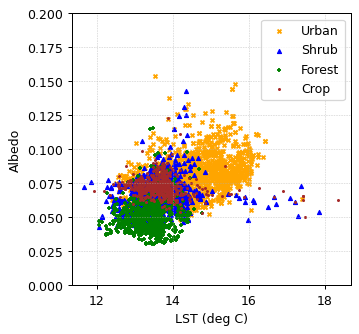

In [269]:
x = LST
y = Alb

plt.subplots(1,1, figsize = (4,4), dpi = 90)
plt.scatter(x[idx_urban], y[idx_urban], s = 10, color = "orange", marker = "x", label = "Urban")
plt.scatter(x[idx_shrub], y[idx_shrub], s = 10, color = "b", marker = "^", label = "Shrub")
plt.scatter(x[idx_forest], y[idx_forest], s = 10, color = "g", marker = "+", label = "Forest")
plt.scatter(x[idx_crop], y[idx_crop], s = 2, color = "brown", label = "Crop")
plt.xlabel("LST (deg C)")
plt.ylabel("Albedo"); plt.ylim(0, 0.2)
plt.grid(ls = ":", lw = 0.5)

plt.legend()
plt.savefig(folder + "Scatter_Alb_" + filename, bbox_inches = "tight")

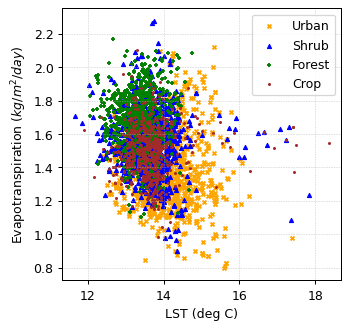

In [270]:
x = LST
y = ET/8

plt.subplots(1,1, figsize = (4,4), dpi = 90)
plt.scatter(x[idx_urban], y[idx_urban], s = 10, color = "orange", marker = "x", label = "Urban")
plt.scatter(x[idx_shrub], y[idx_shrub], s = 10, color = "b", marker = "^", label = "Shrub")
plt.scatter(x[idx_forest], y[idx_forest], s = 10, color = "g", marker = "+", label = "Forest")
plt.scatter(x[idx_crop], y[idx_crop], s = 2, color = "brown", label = "Crop")
plt.xlabel("LST (deg C)")
plt.ylabel("Evapotranspiration $(kg/m^2/day)$"); # plt.ylim(0,0.3)
plt.grid(ls = ":", lw = 0.5)

plt.legend()
plt.savefig(folder + "Scatter_ET_" + filename, bbox_inches = "tight")

In [271]:
folder = "F:\\Heat_Island\\MODIS_LST\\v2\\"
filename = "LSTN_sum"

dataset = gdal.Open(folder + filename + ".tif")
image = dataset.ReadAsArray()
del dataset

LC = image[-1]
LST = image[0] #.flatten()
ET = image[1] #.flatten()
NDVI = image[2] #.flatten()
Alb = image[3] + image[4] #.flatten()

idx_urban = (LC >= 20) & (LC < 30)
idx_forest = (LC >= 40) & (LC < 50)
idx_shrub = (LC >= 50) & (LC < 60)
idx_crop = (LC >= 80) & (LC < 90)

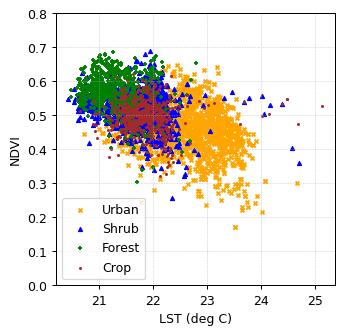

In [272]:
x = LST
y = NDVI

plt.subplots(1,1, figsize = (4,4), dpi = 90)
plt.scatter(x[idx_urban], y[idx_urban], s = 10, color = "orange", marker = "x", label = "Urban")
plt.scatter(x[idx_shrub], y[idx_shrub], s = 10, color = "b", marker = "^", label = "Shrub")
plt.scatter(x[idx_forest], y[idx_forest], s = 10, color = "g", marker = "+", label = "Forest")
plt.scatter(x[idx_crop], y[idx_crop], s = 2, color = "brown", label = "Crop")
plt.xlabel("LST (deg C)")
plt.ylabel("NDVI"); plt.ylim(0,0.8)
plt.grid(ls = ":", lw = 0.5)

plt.legend()
plt.savefig(folder + "Scatter_NDVI_" + filename, bbox_inches = "tight")

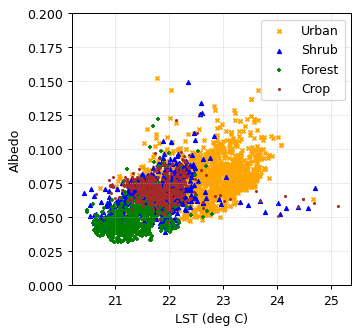

In [273]:
x = LST
y = Alb

plt.subplots(1,1, figsize = (4,4), dpi = 90)
plt.scatter(x[idx_urban], y[idx_urban], s = 10, color = "orange", marker = "x", label = "Urban")
plt.scatter(x[idx_shrub], y[idx_shrub], s = 10, color = "b", marker = "^", label = "Shrub")
plt.scatter(x[idx_forest], y[idx_forest], s = 10, color = "g", marker = "+", label = "Forest")
plt.scatter(x[idx_crop], y[idx_crop], s = 2, color = "brown", label = "Crop")
plt.xlabel("LST (deg C)")
plt.ylabel("Albedo"); plt.ylim(0, 0.2)
plt.grid(ls = ":", lw = 0.5)

plt.legend()
plt.savefig(folder + "Scatter_Alb_" + filename, bbox_inches = "tight")

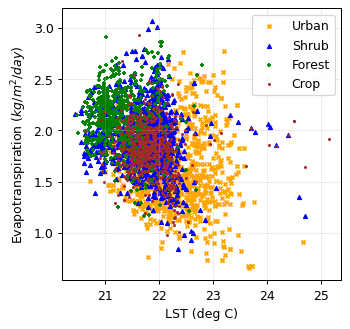

In [274]:
x = LST
y = ET/8

plt.subplots(1,1, figsize = (4,4), dpi = 90)
plt.scatter(x[idx_urban], y[idx_urban], s = 10, color = "orange", marker = "x", label = "Urban")
plt.scatter(x[idx_shrub], y[idx_shrub], s = 10, color = "b", marker = "^", label = "Shrub")
plt.scatter(x[idx_forest], y[idx_forest], s = 10, color = "g", marker = "+", label = "Forest")
plt.scatter(x[idx_crop], y[idx_crop], s = 2, color = "brown", label = "Crop")
plt.xlabel("LST (deg C)")
plt.ylabel("Evapotranspiration $(kg/m^2/day)$"); # plt.ylim(0,0.3)
plt.grid(ls = ":", lw = 0.5)

plt.legend()
plt.savefig(folder + "Scatter_ET_" + filename, bbox_inches = "tight")

In [275]:
folder = "F:\\Heat_Island\\MODIS_LST\\v2\\"
filename = "LSTN_win"

dataset = gdal.Open(folder + filename + ".tif")
image = dataset.ReadAsArray()
del dataset

LC = image[-1]
LST = image[0] #.flatten()
ET = image[1] #.flatten()
NDVI = image[2] #.flatten()
Alb = image[3] + image[4] #.flatten()

idx_urban = (LC >= 20) & (LC < 30)
idx_forest = (LC >= 40) & (LC < 50)
idx_shrub = (LC >= 50) & (LC < 60)
idx_crop = (LC >= 80) & (LC < 90)

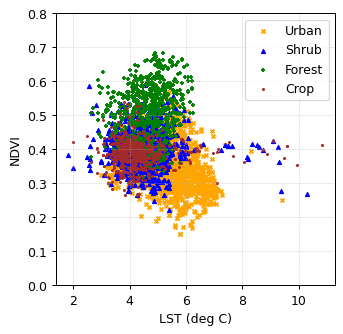

In [276]:
x = LST
y = NDVI

plt.subplots(1,1, figsize = (4,4), dpi = 90)
plt.scatter(x[idx_urban], y[idx_urban], s = 10, color = "orange", marker = "x", label = "Urban")
plt.scatter(x[idx_shrub], y[idx_shrub], s = 10, color = "b", marker = "^", label = "Shrub")
plt.scatter(x[idx_forest], y[idx_forest], s = 10, color = "g", marker = "+", label = "Forest")
plt.scatter(x[idx_crop], y[idx_crop], s = 2, color = "brown", label = "Crop")
plt.xlabel("LST (deg C)")
plt.ylabel("NDVI"); plt.ylim(0,0.8)
plt.grid(ls = ":", lw = 0.5)

plt.legend()
plt.savefig(folder + "Scatter_NDVI_" + filename, bbox_inches = "tight")

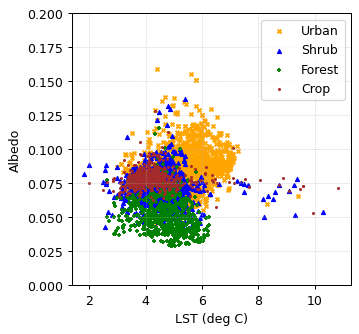

In [277]:
x = LST
y = Alb

plt.subplots(1,1, figsize = (4,4), dpi = 90)
plt.scatter(x[idx_urban], y[idx_urban], s = 10, color = "orange", marker = "x", label = "Urban")
plt.scatter(x[idx_shrub], y[idx_shrub], s = 10, color = "b", marker = "^", label = "Shrub")
plt.scatter(x[idx_forest], y[idx_forest], s = 10, color = "g", marker = "+", label = "Forest")
plt.scatter(x[idx_crop], y[idx_crop], s = 2, color = "brown", label = "Crop")
plt.xlabel("LST (deg C)")
plt.ylabel("Albedo"); plt.ylim(0, 0.2)
plt.grid(ls = ":", lw = 0.5)

plt.legend()
plt.savefig(folder + "Scatter_Alb_" + filename, bbox_inches = "tight")

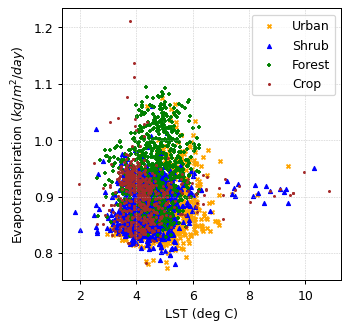

In [278]:
x = LST
y = ET/8

plt.subplots(1,1, figsize = (4,4), dpi = 90)
plt.scatter(x[idx_urban], y[idx_urban], s = 10, color = "orange", marker = "x", label = "Urban")
plt.scatter(x[idx_shrub], y[idx_shrub], s = 10, color = "b", marker = "^", label = "Shrub")
plt.scatter(x[idx_forest], y[idx_forest], s = 10, color = "g", marker = "+", label = "Forest")
plt.scatter(x[idx_crop], y[idx_crop], s = 2, color = "brown", label = "Crop")
plt.xlabel("LST (deg C)")
plt.ylabel("Evapotranspiration $(kg/m^2/day)$"); # plt.ylim(0,0.3)
plt.grid(ls = ":", lw = 0.5)

plt.legend()
plt.savefig(folder + "Scatter_ET_" + filename, bbox_inches = "tight")

In [287]:
LSTD = gdal.Open("F:\\Heat_Island\\MODIS_LST\\v2\\LSTD.tif").ReadAsArray()[0]
LSTN = gdal.Open("F:\\Heat_Island\\MODIS_LST\\v2\\LSTN.tif").ReadAsArray()[0]
LST_diff = LSTD - LSTN

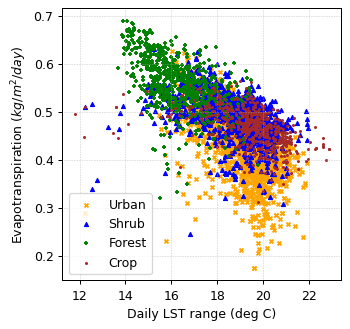

In [288]:
x = LST_diff
y = NDVI

plt.subplots(1,1, figsize = (4,4), dpi = 90)
plt.scatter(x[idx_urban], y[idx_urban], s = 10, color = "orange", marker = "x", label = "Urban")
plt.scatter(x[idx_shrub], y[idx_shrub], s = 10, color = "b", marker = "^", label = "Shrub")
plt.scatter(x[idx_forest], y[idx_forest], s = 10, color = "g", marker = "+", label = "Forest")
plt.scatter(x[idx_crop], y[idx_crop], s = 2, color = "brown", label = "Crop")
plt.xlabel("Daily LST range (deg C)")
plt.ylabel("Evapotranspiration $(kg/m^2/day)$"); # plt.ylim(0,0.3)
plt.grid(ls = ":", lw = 0.5)

plt.legend()
# plt.savefig(folder + "Scatter_ET_" + filename, bbox_inches = "tight")

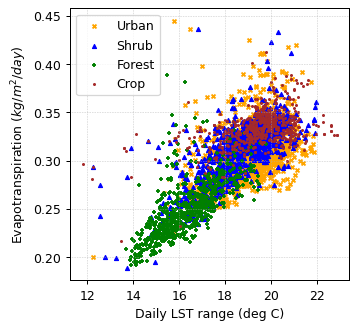

In [289]:
x = LST_diff
y = Alb

plt.subplots(1,1, figsize = (4,4), dpi = 90)
plt.scatter(x[idx_urban], y[idx_urban], s = 10, color = "orange", marker = "x", label = "Urban")
plt.scatter(x[idx_shrub], y[idx_shrub], s = 10, color = "b", marker = "^", label = "Shrub")
plt.scatter(x[idx_forest], y[idx_forest], s = 10, color = "g", marker = "+", label = "Forest")
plt.scatter(x[idx_crop], y[idx_crop], s = 2, color = "brown", label = "Crop")
plt.xlabel("Albedo")
plt.ylabel("Evapotranspiration $(kg/m^2/day)$"); # plt.ylim(0,0.3)
plt.grid(ls = ":", lw = 0.5)

plt.legend()
# plt.savefig(folder + "Scatter_ET_" + filename, bbox_inches = "tight")

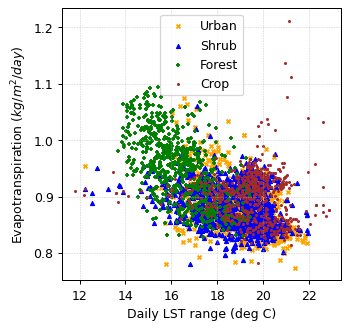

In [282]:
x = LST_diff
y = ET/8

plt.subplots(1,1, figsize = (4,4), dpi = 90)
plt.scatter(x[idx_urban], y[idx_urban], s = 10, color = "orange", marker = "x", label = "Urban")
plt.scatter(x[idx_shrub], y[idx_shrub], s = 10, color = "b", marker = "^", label = "Shrub")
plt.scatter(x[idx_forest], y[idx_forest], s = 10, color = "g", marker = "+", label = "Forest")
plt.scatter(x[idx_crop], y[idx_crop], s = 2, color = "brown", label = "Crop")
plt.xlabel("Daily LST range (deg C)")
plt.ylabel("Evapotranspiration $(kg/m^2/day)$"); # plt.ylim(0,0.3)
plt.grid(ls = ":", lw = 0.5)

plt.legend()
# plt.savefig(folder + "Scatter_ET_" + filename, bbox_inches = "tight")

## Time series of Albedo

In [ ]:
def create_df_roi(img):
    dt_list = img.reduceColumns(ee.Reducer.toList(2), ['date','temp']).values().get(0)
    df_dt = pd.DataFrame(dt_list.getInfo(), columns=['date', 'temp'])
    df_dt['date'] = pd.to_datetime(df_dt['date'])
    return df_dt

def temp_total(img):
    mean = img.multiply(0.001).reduceRegion(reducer=ee.Reducer.median(), geometry=Bexar, scale=1000).get(field)
    return img.set('date', img.date().format()).set('temp',mean)

def temp_d_high(img):
    mean = img.multiply(0.001).reduceRegion(reducer=ee.Reducer.median(), geometry=d_high, scale=1000).get(field)
    return img.set('date', img.date().format()).set('temp',mean)

def temp_d_low(img):
    mean = img.multiply(0.001).reduceRegion(reducer=ee.Reducer.median(), geometry=d_low, scale=1000).get(field)
    return img.set('date', img.date().format()).set('temp',mean)

def temp_forest(img):
    mean = img.multiply(0.001).reduceRegion(reducer=ee.Reducer.median(), geometry=forest, scale=1000).get(field)
    return img.set('date', img.date().format()).set('temp',mean)

def temp_crops(img):
    mean = img.multiply(0.001).reduceRegion(reducer=ee.Reducer.median(), geometry=crops, scale=1000).get(field)
    return img.set('date', img.date().format()).set('temp',mean)

def temp_shrub(img):
    mean = img.multiply(0.001).reduceRegion(reducer=ee.Reducer.median(), geometry=shrub, scale=1000).get(field)
    return img.set('date', img.date().format()).set('temp',mean)

def temp_wetland(img):
    mean = img.multiply(0.001).reduceRegion(reducer=ee.Reducer.median(), geometry=wetland, scale=1000).get(field)
    return img.set('date', img.date().format()).set('temp',mean)

def temp_road(img):
    mean = img.multiply(0.001).reduceRegion(reducer=ee.Reducer.median(), geometry=road_buf, scale=1000).get(field)
    return img.set('date', img.date().format()).set('temp',mean)

def temp_nroad(img):
    mean = img.multiply(0.001).reduceRegion(reducer=ee.Reducer.median(), geometry=non_road, scale=1000).get(field)
    return img.set('date', img.date().format()).set('temp',mean)

# MODIS Aqua Day data (1:30 pm)
field = 'Albedo_WSA_shortwave'
col = ee.ImageCollection("MODIS/061/MCD43A3").select(field).filterDate('2000-01-01', '2023-01-01')

img_total = col.map(temp_total)
img_d_high = col.map(temp_d_high)
img_d_low = col.map(temp_d_low)
img_forest = col.map(temp_forest)
img_crops = col.map(temp_crops)
img_shrub = col.map(temp_shrub)
img_wetland = col.map(temp_wetland)
# img_road = col.map(temp_road)
# img_nroad = col.map(temp_nroad)

# Total temperautre
df = create_df_roi(img_total)
df["month"] = pd.DatetimeIndex(df['date']).month
df["year"] = pd.DatetimeIndex(df['date']).year

# Temperature for each region
df_d_high = create_df_roi(img_d_high)
df_d_low = create_df_roi(img_d_low)
df_forest = create_df_roi(img_forest)
df_crops = create_df_roi(img_crops)
df_shrub = create_df_roi(img_shrub)
df_wetland = create_df_roi(img_wetland)
# df_road = create_df_roi(img_road)
# df_nroad = create_df_roi(img_nroad)

df = df.join(df_d_high.set_index("date"), on="date", lsuffix='', rsuffix='_dhi')
df = df.join(df_d_low.set_index("date"), on="date", lsuffix='', rsuffix='_dlo')
df = df.join(df_forest.set_index("date"), on="date", lsuffix='', rsuffix='_for')
df = df.join(df_shrub.set_index("date"), on="date", lsuffix='', rsuffix='_shr')
df = df.join(df_crops.set_index("date"), on="date", lsuffix='', rsuffix='_cro')
df = df.join(df_wetland.set_index("date"), on="date", lsuffix='', rsuffix='_wet')
# df = df.join(df_road.set_index("date"), on="date", lsuffix='', rsuffix='_rd')
# df = df.join(df_nroad.set_index("date"), on="date", lsuffix='', rsuffix='_nrd')

df.to_csv("F:\\Heat_Island\\{0}_SA_2002-2022.csv".format(field))

df

In [310]:
def create_df_roi(img):
    dt_list = img.reduceColumns(ee.Reducer.toList(2), ['date','temp']).values().get(0)
    df_dt = pd.DataFrame(dt_list.getInfo(), columns=['date', 'temp'])
    df_dt['date'] = pd.to_datetime(df_dt['date'])
    return df_dt

def temp_total(img):
    mean = img.multiply(0.1).reduceRegion(reducer=ee.Reducer.median(), geometry=Bexar, scale=1000).get(field)
    return img.set('date', img.date().format()).set('temp',mean)

def temp_d_high(img):
    mean = img.multiply(0.1).reduceRegion(reducer=ee.Reducer.median(), geometry=d_high, scale=1000).get(field)
    return img.set('date', img.date().format()).set('temp',mean)

def temp_d_low(img):
    mean = img.multiply(0.1).reduceRegion(reducer=ee.Reducer.median(), geometry=d_low, scale=1000).get(field)
    return img.set('date', img.date().format()).set('temp',mean)

def temp_forest(img):
    mean = img.multiply(0.1).reduceRegion(reducer=ee.Reducer.median(), geometry=forest, scale=1000).get(field)
    return img.set('date', img.date().format()).set('temp',mean)

def temp_crops(img):
    mean = img.multiply(0.1).reduceRegion(reducer=ee.Reducer.median(), geometry=crops, scale=1000).get(field)
    return img.set('date', img.date().format()).set('temp',mean)

def temp_shrub(img):
    mean = img.multiply(0.1).reduceRegion(reducer=ee.Reducer.median(), geometry=shrub, scale=1000).get(field)
    return img.set('date', img.date().format()).set('temp',mean)

def temp_wetland(img):
    mean = img.multiply(0.1).reduceRegion(reducer=ee.Reducer.median(), geometry=wetland, scale=1000).get(field)
    return img.set('date', img.date().format()).set('temp',mean)

def temp_road(img):
    mean = img.multiply(0.1).reduceRegion(reducer=ee.Reducer.median(), geometry=road_buf, scale=1000).get(field)
    return img.set('date', img.date().format()).set('temp',mean)

def temp_nroad(img):
    mean = img.multiply(0.1).reduceRegion(reducer=ee.Reducer.median(), geometry=non_road, scale=1000).get(field)
    return img.set('date', img.date().format()).set('temp',mean)

# MODIS Aqua Day data (1:30 pm)
field = 'ET'
col = ee.ImageCollection("MODIS/006/MOD16A2").select(field).filterDate('2000-01-01', '2023-01-01')

img_total = col.map(temp_total)
img_d_high = col.map(temp_d_high)
img_d_low = col.map(temp_d_low)
img_forest = col.map(temp_forest)
img_crops = col.map(temp_crops)
img_shrub = col.map(temp_shrub)
img_wetland = col.map(temp_wetland)
# img_road = col.map(temp_road)
# img_nroad = col.map(temp_nroad)

# Total temperautre
df = create_df_roi(img_total)
df["month"] = pd.DatetimeIndex(df['date']).month
df["year"] = pd.DatetimeIndex(df['date']).year

# Temperature for each region
df_d_high = create_df_roi(img_d_high)
df_d_low = create_df_roi(img_d_low)
df_forest = create_df_roi(img_forest)
df_crops = create_df_roi(img_crops)
df_shrub = create_df_roi(img_shrub)
df_wetland = create_df_roi(img_wetland)
# df_road = create_df_roi(img_road)
# df_nroad = create_df_roi(img_nroad)

df = df.join(df_d_high.set_index("date"), on="date", lsuffix='', rsuffix='_dhi')
df = df.join(df_d_low.set_index("date"), on="date", lsuffix='', rsuffix='_dlo')
df = df.join(df_forest.set_index("date"), on="date", lsuffix='', rsuffix='_for')
df = df.join(df_shrub.set_index("date"), on="date", lsuffix='', rsuffix='_shr')
df = df.join(df_crops.set_index("date"), on="date", lsuffix='', rsuffix='_cro')
df = df.join(df_wetland.set_index("date"), on="date", lsuffix='', rsuffix='_wet')
# df = df.join(df_road.set_index("date"), on="date", lsuffix='', rsuffix='_rd')
# df = df.join(df_nroad.set_index("date"), on="date", lsuffix='', rsuffix='_nrd')

df.to_csv("F:\\Heat_Island\\{0}_SA_2002-2022.csv".format(field))

df

,date,temp,month,year,temp_dhi,temp_dlo,temp_for,temp_shr,temp_cro,temp_wet
0,2001-01-01,16.051329,1,2001,15.550233,15.3,18.7,15.4,15.3,13.7
1,2001-01-09,8.000000,1,2001,7.700000,8.2,8.0,8.0,7.9,7.4
2,2001-01-17,7.800000,1,2001,7.800000,7.9,7.8,7.9,8.0,7.5
3,2001-01-25,9.500000,1,2001,9.200000,9.3,9.7,9.6,9.9,8.8
4,2001-02-02,10.900000,2,2001,10.500000,10.8,11.2,10.8,11.0,9.9
...,...,...,...,...,...,...,...,...,...,...
998,2022-11-25,9.300000,11,2022,9.000000,9.2,9.2,9.3,9.6,8.3
999,2022-12-03,13.800000,12,2022,NaN,14.6,13.5,13.8,15.9,NaN
1000,2022-12-11,8.500000,12,2022,8.300000,8.3,8.7,8.5,8.4,8.1
1001,2022-12-19,6.700000,12,2022,6.900000,6.7,6.8,6.6,6.5,7.0


In [311]:
def create_df_roi(img):
    dt_list = img.reduceColumns(ee.Reducer.toList(2), ['date','temp']).values().get(0)
    df_dt = pd.DataFrame(dt_list.getInfo(), columns=['date', 'temp'])
    df_dt['date'] = pd.to_datetime(df_dt['date'])
    return df_dt

def temp_total(img):
    mean = img.multiply(0.0001).reduceRegion(reducer=ee.Reducer.median(), geometry=Bexar, scale=1000).get(field)
    return img.set('date', img.date().format()).set('temp',mean)

def temp_d_high(img):
    mean = img.multiply(0.0001).reduceRegion(reducer=ee.Reducer.median(), geometry=d_high, scale=1000).get(field)
    return img.set('date', img.date().format()).set('temp',mean)

def temp_d_low(img):
    mean = img.multiply(0.0001).reduceRegion(reducer=ee.Reducer.median(), geometry=d_low, scale=1000).get(field)
    return img.set('date', img.date().format()).set('temp',mean)

def temp_forest(img):
    mean = img.multiply(0.0001).reduceRegion(reducer=ee.Reducer.median(), geometry=forest, scale=1000).get(field)
    return img.set('date', img.date().format()).set('temp',mean)

def temp_crops(img):
    mean = img.multiply(0.0001).reduceRegion(reducer=ee.Reducer.median(), geometry=crops, scale=1000).get(field)
    return img.set('date', img.date().format()).set('temp',mean)

def temp_shrub(img):
    mean = img.multiply(0.0001).reduceRegion(reducer=ee.Reducer.median(), geometry=shrub, scale=1000).get(field)
    return img.set('date', img.date().format()).set('temp',mean)

def temp_wetland(img):
    mean = img.multiply(0.0001).reduceRegion(reducer=ee.Reducer.median(), geometry=wetland, scale=1000).get(field)
    return img.set('date', img.date().format()).set('temp',mean)

def temp_road(img):
    mean = img.multiply(0.0001).reduceRegion(reducer=ee.Reducer.median(), geometry=road_buf, scale=1000).get(field)
    return img.set('date', img.date().format()).set('temp',mean)

def temp_nroad(img):
    mean = img.multiply(0.0001).reduceRegion(reducer=ee.Reducer.median(), geometry=non_road, scale=1000).get(field)
    return img.set('date', img.date().format()).set('temp',mean)

# MODIS Aqua Day data (1:30 pm)
field = 'NDVI'
col = ee.ImageCollection("MODIS/061/MYD13A2").select(field).filterDate('2000-01-01', '2023-01-01')

img_total = col.map(temp_total)
img_d_high = col.map(temp_d_high)
img_d_low = col.map(temp_d_low)
img_forest = col.map(temp_forest)
img_crops = col.map(temp_crops)
img_shrub = col.map(temp_shrub)
img_wetland = col.map(temp_wetland)
# img_road = col.map(temp_road)
# img_nroad = col.map(temp_nroad)

# Total temperautre
df = create_df_roi(img_total)
df["month"] = pd.DatetimeIndex(df['date']).month
df["year"] = pd.DatetimeIndex(df['date']).year

# Temperature for each region
df_d_high = create_df_roi(img_d_high)
df_d_low = create_df_roi(img_d_low)
df_forest = create_df_roi(img_forest)
df_crops = create_df_roi(img_crops)
df_shrub = create_df_roi(img_shrub)
df_wetland = create_df_roi(img_wetland)
# df_road = create_df_roi(img_road)
# df_nroad = create_df_roi(img_nroad)

df = df.join(df_d_high.set_index("date"), on="date", lsuffix='', rsuffix='_dhi')
df = df.join(df_d_low.set_index("date"), on="date", lsuffix='', rsuffix='_dlo')
df = df.join(df_forest.set_index("date"), on="date", lsuffix='', rsuffix='_for')
df = df.join(df_shrub.set_index("date"), on="date", lsuffix='', rsuffix='_shr')
df = df.join(df_crops.set_index("date"), on="date", lsuffix='', rsuffix='_cro')
df = df.join(df_wetland.set_index("date"), on="date", lsuffix='', rsuffix='_wet')
# df = df.join(df_road.set_index("date"), on="date", lsuffix='', rsuffix='_rd')
# df = df.join(df_nroad.set_index("date"), on="date", lsuffix='', rsuffix='_nrd')

df.to_csv("F:\\Heat_Island\\{0}_SA_2002-2022.csv".format(field))

df

,date,temp,month,year,temp_dhi,temp_dlo,temp_for,temp_shr,temp_cro,temp_wet
0,2002-07-04,0.560398,7,2002,0.489754,0.545460,0.584285,0.591566,0.579927,0.4670
1,2002-07-20,0.603467,7,2002,0.517624,0.568444,0.599503,0.654375,0.649597,0.5800
2,2002-08-05,0.576152,8,2002,0.502395,0.552652,0.619129,0.603220,0.579640,0.4134
3,2002-08-21,0.513609,8,2002,0.458925,0.501693,0.579892,0.521541,0.500970,0.4114
4,2002-09-06,0.615148,9,2002,0.525312,0.583418,0.669838,0.642361,0.625891,0.5449
...,...,...,...,...,...,...,...,...,...,...
467,2022-10-24,0.377005,10,2022,0.345933,0.376917,0.513634,0.369076,0.344744,0.2936
468,2022-11-09,0.396393,11,2022,0.357128,0.399740,0.529062,0.387763,0.371941,0.2935
469,2022-11-25,0.388650,11,2022,0.345757,0.388621,0.521449,0.384813,0.381946,0.3185
470,2022-12-11,0.423683,12,2022,0.356495,0.408822,0.545144,0.427390,0.434733,0.3395


In [328]:
alb = pd.read_csv("F:\\Heat_Island\\Albedo_WSA_shortwave_SA_2002-2022.csv", index_col = 0)\
.groupby(by=["year", "month"], as_index=False).mean()
et = pd.read_csv("F:\\Heat_Island\\ET_SA_2002-2022.csv", index_col = 0)\
.groupby(by=["year", "month"], as_index=False).mean()
ndvi = pd.read_csv("F:\\Heat_Island\\NDVI_SA_2002-2022.csv", index_col = 0)\
.groupby(by=["year", "month"], as_index=False).mean()
lst_day = pd.read_csv("F:\\Heat_Island\\LST_Day_1km_SA_2002-2022.csv", index_col = 0)\
.groupby(by=["year", "month"], as_index=False).mean()
lst_night = pd.read_csv("F:\\Heat_Island\\LST_Night_1km_SA_2002-2022.csv", index_col = 0)\
.groupby(by=["year", "month"], as_index=False).mean()

alb = alb[alb["year"] >= 2003].reset_index(drop = True)
et = et[et["year"] >= 2003].reset_index(drop = True)
ndvi = ndvi[ndvi["year"] >= 2003].reset_index(drop = True)
lst_day = lst_day[lst_day["year"] >= 2003].reset_index(drop = True)
lst_night = lst_night[lst_night["year"] >= 2003].reset_index(drop = True)

In [329]:
print(len(alb))
print(len(et))
print(len(ndvi))
print(len(lst_day))

240
240
240
240


In [333]:
lst_day.keys()

Index(['year', 'month', 'temp', 'temp_dhi', 'temp_dlo', 'temp_for', 'temp_shr',
       'temp_cro', 'temp_wet', 'temp_rd', 'temp_nrd'],
      dtype='object')

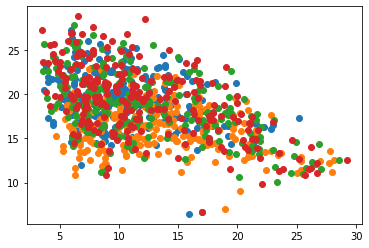

In [359]:
x = et
field = "temp_dhi"
plt.scatter(x[field], lst_day[field]-lst_night[field])
field = "temp_for"
plt.scatter(x[field], lst_day[field]-lst_night[field])
field = "temp_shr"
plt.scatter(x[field], lst_day[field]-lst_night[field])
field = "temp_cro"
plt.scatter(x[field], lst_day[field]-lst_night[field])

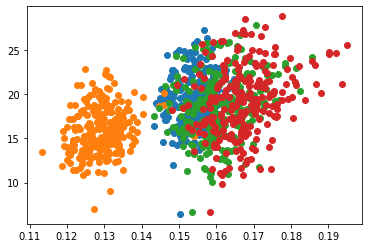

In [361]:
x = alb
field = "temp_dhi"
plt.scatter(x[field], lst_day[field]-lst_night[field])
field = "temp_for"
plt.scatter(x[field], lst_day[field]-lst_night[field])
field = "temp_shr"
plt.scatter(x[field], lst_day[field]-lst_night[field])
field = "temp_cro"
plt.scatter(x[field], lst_day[field]-lst_night[field])

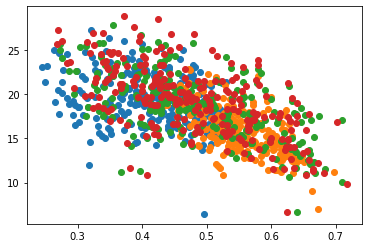

In [362]:
x = ndvi
field = "temp_dhi"
plt.scatter(x[field], lst_day[field]-lst_night[field])
field = "temp_for"
plt.scatter(x[field], lst_day[field]-lst_night[field])
field = "temp_shr"
plt.scatter(x[field], lst_day[field]-lst_night[field])
field = "temp_cro"
plt.scatter(x[field], lst_day[field]-lst_night[field])

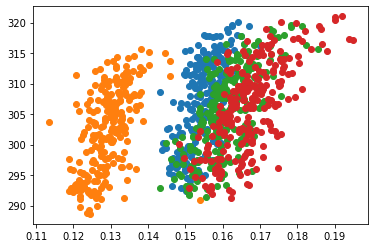

In [364]:
x = alb
field = "temp_dhi"
plt.scatter(x[field], lst_day[field])
field = "temp_for"
plt.scatter(x[field], lst_day[field])
field = "temp_shr"
plt.scatter(x[field], lst_day[field])
field = "temp_cro"
plt.scatter(x[field], lst_day[field])

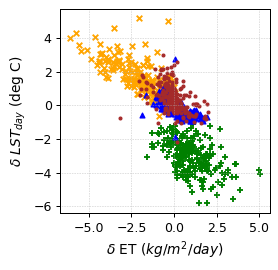

In [514]:
folder = "F:\\Heat_Island\\MODIS_LST\\v2\\"

plt.subplots(1,1, figsize = (3,3), dpi = 90)
x = et
y = lst_day
plt.scatter(x["temp_dhi"] - x["temp"], y["temp_dhi"] - y["temp"], s = 20, color = "orange", marker = "x", label = "Urban")
# plt.scatter(x["temp_dlo"] - x["temp"], y["temp_dlo"] - y["temp"])

plt.scatter(x["temp_for"] - x["temp"], y["temp_for"] - y["temp"], s = 30, color = "g", marker = "+", label = "Forest")
plt.scatter(x["temp_shr"] - x["temp"], y["temp_shr"] - y["temp"], s = 15, color = "b", marker = "^", label = "Shrub")
plt.scatter(x["temp_cro"] - x["temp"], y["temp_cro"] - y["temp"], s = 5, color = "brown", label = "Crop")
# plt.legend(bbox_to_anchor = (1.5, 1), handletextpad = 0, ncol = 4)
plt.grid(ls = ":", lw = 0.5)
plt.xlabel("$\delta$ ET $(kg/m^2/day)$", fontsize = 11)
plt.ylabel("$\delta$ $LST_{day}$ (deg C)", fontsize = 11)

plt.savefig(folder + "Scatter_ET_ddayLST", bbox_inches = "tight")

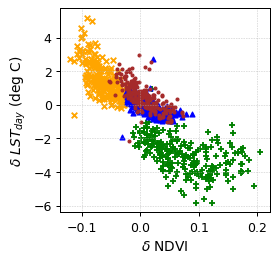

In [506]:
plt.subplots(1,1, figsize = (3,3), dpi = 90)
x = ndvi
y = lst_day
plt.scatter(x["temp_dhi"] - x["temp"], y["temp_dhi"] - y["temp"], s = 20, color = "orange", marker = "x", label = "Urban")
# plt.scatter(x["temp_dlo"] - x["temp"], y["temp_dlo"] - y["temp"])

plt.scatter(x["temp_for"] - x["temp"], y["temp_for"] - y["temp"], s = 30, color = "g", marker = "+", label = "Forest")
plt.scatter(x["temp_shr"] - x["temp"], y["temp_shr"] - y["temp"], s = 15, color = "b", marker = "^", label = "Shrub")
plt.scatter(x["temp_cro"] - x["temp"], y["temp_cro"] - y["temp"], s = 5, color = "brown", label = "Crop")
# plt.legend(bbox_to_anchor = (1.5, 1), handletextpad = 0)
plt.grid(ls = ":", lw = 0.5)
plt.xlabel("$\delta$ NDVI", fontsize = 11)
plt.ylabel("$\delta$ $LST_{day}$ (deg C)", fontsize = 11)

plt.savefig(folder + "Scatter_NDVI_ddayLST", bbox_inches = "tight")

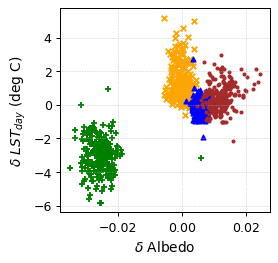

In [507]:
plt.subplots(1,1, figsize = (3,3), dpi = 90)
x = alb
y = lst_day
plt.scatter(x["temp_dhi"] - x["temp"], y["temp_dhi"] - y["temp"], s = 20, color = "orange", marker = "x", label = "Urban")
# plt.scatter(x["temp_dlo"] - x["temp"], y["temp_dlo"] - y["temp"])

plt.scatter(x["temp_for"] - x["temp"], y["temp_for"] - y["temp"], s = 30, color = "g", marker = "+", label = "Forest")
plt.scatter(x["temp_shr"] - x["temp"], y["temp_shr"] - y["temp"], s = 15, color = "b", marker = "^", label = "Shrub")
plt.scatter(x["temp_cro"] - x["temp"], y["temp_cro"] - y["temp"], s = 5, color = "brown", label = "Crop")
# plt.legend(bbox_to_anchor = (1.5, 1), handletextpad = 0)
plt.grid(ls = ":", lw = 0.5)
plt.xlabel("$\delta$ Albedo", fontsize = 11)
plt.ylabel("$\delta$ $LST_{day}$ (deg C)", fontsize = 11)

plt.savefig(folder + "Scatter_alb_ddayLST", bbox_inches = "tight")

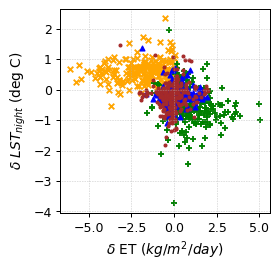

In [508]:
folder = "F:\\Heat_Island\\MODIS_LST\\v2\\"

plt.subplots(1,1, figsize = (3,3), dpi = 90)
x = et
y = lst_night
plt.scatter(x["temp_dhi"] - x["temp"], y["temp_dhi"] - y["temp"], s = 20, color = "orange", marker = "x", label = "Urban")
# plt.scatter(x["temp_dlo"] - x["temp"], y["temp_dlo"] - y["temp"])

plt.scatter(x["temp_for"] - x["temp"], y["temp_for"] - y["temp"], s = 30, color = "g", marker = "+", label = "Forest")
plt.scatter(x["temp_shr"] - x["temp"], y["temp_shr"] - y["temp"], s = 15, color = "b", marker = "^", label = "Shrub")
plt.scatter(x["temp_cro"] - x["temp"], y["temp_cro"] - y["temp"], s = 5, color = "brown", label = "Crop")
# plt.legend(bbox_to_anchor = (1.5, 1), handletextpad = 0)
plt.grid(ls = ":", lw = 0.5)
plt.xlabel("$\delta$ ET $(kg/m^2/day)$", fontsize = 11)
plt.ylabel("$\delta$ $LST_{night}$ (deg C)", fontsize = 11)

plt.savefig(folder + "Scatter_ET_dnightLST", bbox_inches = "tight")

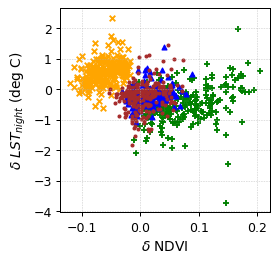

In [509]:
plt.subplots(1,1, figsize = (3,3), dpi = 90)
x = ndvi
y = lst_night
plt.scatter(x["temp_dhi"] - x["temp"], y["temp_dhi"] - y["temp"], s = 20, color = "orange", marker = "x", label = "Urban")
# plt.scatter(x["temp_dlo"] - x["temp"], y["temp_dlo"] - y["temp"])

plt.scatter(x["temp_for"] - x["temp"], y["temp_for"] - y["temp"], s = 30, color = "g", marker = "+", label = "Forest")
plt.scatter(x["temp_shr"] - x["temp"], y["temp_shr"] - y["temp"], s = 15, color = "b", marker = "^", label = "Shrub")
plt.scatter(x["temp_cro"] - x["temp"], y["temp_cro"] - y["temp"], s = 5, color = "brown", label = "Crop")
# plt.legend(bbox_to_anchor = (1.5, 1), handletextpad = 0)
plt.grid(ls = ":", lw = 0.5)
plt.xlabel("$\delta$ NDVI", fontsize = 11)
plt.ylabel("$\delta$ $LST_{night}$ (deg C)", fontsize = 11)

plt.savefig(folder + "Scatter_NDVI_dnightLST", bbox_inches = "tight")

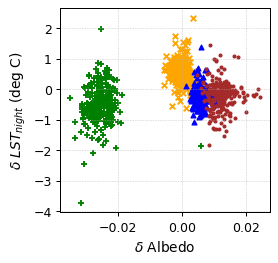

In [510]:
plt.subplots(1,1, figsize = (3,3), dpi = 90)
x = alb
y = lst_night
plt.scatter(x["temp_dhi"] - x["temp"], y["temp_dhi"] - y["temp"], s = 20, color = "orange", marker = "x", label = "Urban")
# plt.scatter(x["temp_dlo"] - x["temp"], y["temp_dlo"] - y["temp"])

plt.scatter(x["temp_for"] - x["temp"], y["temp_for"] - y["temp"], s = 30, color = "g", marker = "+", label = "Forest")
plt.scatter(x["temp_shr"] - x["temp"], y["temp_shr"] - y["temp"], s = 15, color = "b", marker = "^", label = "Shrub")
plt.scatter(x["temp_cro"] - x["temp"], y["temp_cro"] - y["temp"], s = 5, color = "brown", label = "Crop")
# plt.legend(bbox_to_anchor = (1.5, 1), handletextpad = 0)
plt.grid(ls = ":", lw = 0.5)
plt.xlabel("$\delta$ Albedo", fontsize = 11)
plt.ylabel("$\delta$ $LST_{night}$ (deg C)", fontsize = 11)

plt.savefig(folder + "Scatter_alb_dnightLST", bbox_inches = "tight")

In [520]:
x = alb
y = lst_night

for field in ["temp_dhi", "temp_cro", "temp_shr", "temp_for"]:
    x1 = x[field] - x["temp"]
    y1 = y[field] - y["temp"]
    r, p = stats.pearsonr(x1, y1)
    print(field, " {0:.2f}, {1:.2f}".format(r, p))

temp_dhi  -0.15, 0.02
temp_cro  0.00, 0.98
temp_shr  -0.03, 0.66
temp_for  0.07, 0.32


### Last update: 10/12/2022
### Credited by YoungHyun Koo (kooala317@gmail.com)